[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter11_lecture_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Chapter 11: Spectral and wavelet analysis

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The spectral representation; estimation theory: lag windows, bandwidth, multitaper (Thomson 1982).
- Two series: coherence, phase, gain, dynamic correlation (Croux, Forni and Reichlin 2001), causality by frequency (Geweke 1982; Breitung and Candelon 2006).
- Filters and the business cycle: Baxter-King, Christiano-Fitzgerald, HP and Hamilton (2018); Romania and the euro area.
- Evolutionary spectra; wavelets: MODWT, wavelet variance and correlation by scale, wavelet coherence with Monte Carlo significance (Torrence and Compo 1998; Grinsted et al. 2004).
- Conventions: f(w) = (2 pi)^-1 sum gamma(h) exp(-i w h); growth rates and returns are 100 x log differences.
- Some computations use fewer replications than the slides, to keep the run short.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_11'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/ATS - Modelarea avansata a seriilor de timp/repo/notebooks/EN


In [2]:
# PyWavelets gives the wavelet filters (Colab: installed here if missing)
%pip install -q PyWavelets

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## The numpy engine and the data helpers

- Spectra: `periodogram`, `lag_window`, `daniell`, `welch`, `multitaper` (with adaptive weights), `harmonic_ftest`.
- Two series: `cross_spectrum` (coherence, phase, gain, dynamic correlation), `geweke`, `breitung_candelon`.
- Filters: `hp_filter`, `bk_filter`, `hamilton_filter` and their gains.
- Wavelets: `modwt`, `mra`, `wavelet_variance`, `wavelet_corr`, `cwt`, `wavelet_coherence`, `wtc_montecarlo`.
- Data: Eurostat (GDP, industrial production, HICP) and FRED (Brent) online; EODHD closes from the course repository.

In [6]:
import time
from scipy import signal, sparse, linalg
from scipy.sparse.linalg import spsolve
from scipy.ndimage import convolve1d
SEED = 2026
END = '2026-09-18'
PW_AR4 = (2.7607, -3.8106, 2.6535, -0.9238)
AR2 = (1.3, -0.7)
AR2_SHARP = (1.6, -0.9)
BC_Q = (6, 32)
BC_M = (18, 96)
CEE = ['RO', 'PL', 'HU', 'CZ']
GEO_LAB = {'RO': 'Romania', 'PL': 'Poland', 'HU': 'Hungary', 'CZ': 'Czechia', 'EA20': 'euro area', 'EA': 'euro area'}
GEO_COL = {'RO': st.IDAred, 'PL': st.Purple, 'HU': st.Forest, 'CZ': st.Orange, 'EA20': st.MainBlue, 'EA': st.MainBlue}
_MEM = {}
W0 = 6.0
FOURIER_FACTOR = 4 * np.pi / (W0 + np.sqrt(2 + W0 ** 2))
KERNEL_CONST = {'bartlett': (1.0, 1.0, 0.6666666666666666), 'parzen': (2.0, 6.0, 0.539285), 'qs': (2.0, 1.421223, 1.0), 'tukey': (2.0, 2.4674011002723395, 0.75)}
_DPSS = {}


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def online(fn, *a, tries=4, **k):
    """Online sources (Eurostat, FRED) with a few retries."""
    key = (fn.__name__,) + a + tuple(sorted(k.items()))
    if key in _MEM:
        return _MEM[key]
    for i in range(tries):
        try:
            _MEM[key] = fn(*a, **k)
            return _MEM[key]
        except Exception:
            if i == tries - 1:
                raise
            time.sleep(5 * (i + 1))


def gdp(geo, end='2026-06-30'):
    """100 x log real GDP (chain-linked volumes 2010, seasonally and calendar adjusted), Eurostat namq_10_gdp."""
    s = online(read_eurostat, 'namq_10_gdp', f'Q.CLV10_MEUR.SCA.B1GQ.{geo}')
    return (100 * np.log(s.loc['1995-01-01':end])).rename(geo)


def ip(geo, adj='SCA'):
    """100 x log industrial production (B-D: mining, manufacturing, energy), 2021 = 100, Eurostat sts_inpr_m."""
    s = online(read_eurostat, 'sts_inpr_m', f'M.PRD.B-D.{adj}.I21.{geo}')
    return (100 * np.log(s.loc['2000-01-01':])).rename(geo)


def hicp(geo, start='2001-01-01'):
    """HICP annual rate of change (%), all items, Eurostat prc_hicp_minr."""
    s = online(read_eurostat, 'prc_hicp_minr', f'M.RCH_A.TOTAL.{geo}')
    return s.loc[start:].rename(geo)


def weekly_returns(name, start='2000-01-01', end=END):
    """Weekly log returns in % from Friday closes (the last close of each week)."""
    p = load_close(name, start=start, end=end).resample('W-FRI').last().dropna()
    return (100 * np.log(p).diff().dropna()).rename(name)


def brent_weekly(start='2000-01-01', end=END):
    p = online(read_fred, 'DCOILBRENTEU').loc[start:end].dropna()
    p = p[p > 0].resample('W-FRI').last().dropna()
    return (100 * np.log(p).diff().dropna()).rename('brent')


def daily_common(names, start='2000-01-01', end=END):
    """Daily log returns in % on the days on which all markets traded (prices aligned first)."""
    p = pd.concat([load_close(n, start=start, end=end) for n in names], axis=1, join='inner').dropna()
    return 100 * np.log(p).diff().dropna()


def per_axis(ax, lo, hi, ticks, label='period'):
    """Logarithmic period axis (long cycles on the left)."""
    ax.set_xscale('log')
    ax.set_xlim(hi, lo)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.minorticks_off()
    ax.set_xlabel(label)


def shade_band(ax, lo, hi, label='business-cycle band'):
    ax.axvspan(lo, hi, color=st.Amber, alpha=0.15, lw=0, label=label)


def ip_growth(geo, adj='SCA'):
    return ip(geo, adj).diff().dropna()


def gdp_growth(geo, end='2026-06-30'):
    return gdp(geo, end).diff().dropna()


def bet_daily():
    return (100 * np.log(load_close('bet', start='2000-01-01', end=END)).diff().dropna()).rename('bet')


def year_axis(n, idx):
    """Positions and labels of every fifth year on an index of dates."""
    yrs = sorted({d.year for d in idx if d.year % 5 == 0})
    pos = [int(np.argmax(idx >= pd.Timestamp(f'{y}-01-01'))) for y in yrs]
    return pos, [str(y) for y in yrs]


def plot_tf(ax, Z, c, idx, levels, cmap='viridis', sig=None, sig_level=1.0, phase=None, arrows_where=None):
    """Time-period plot with log2 period axis, the cone of influence hatched and optional significance contours
    and phase arrows (right: in phase; left: anti-phase; up: the first series leads)."""
    n = Z.shape[1]
    t = np.arange(n)
    lp = np.log2(c['period'])
    cf = ax.contourf(t, lp, Z, levels=levels, cmap=cmap, extend='both')
    if sig is not None:
        ax.contour(t, lp, sig, levels=[sig_level], colors=[st.DarkText], linewidths=1.0)
    coi = np.log2(np.maximum(c['coi'], c['period'][0]))
    ax.fill_between(t, coi, lp[-1], facecolor='white', alpha=0.45, hatch='xx', edgecolor=st.DarkText, lw=0)
    if phase is not None:
        step_t = max(n // 45, 1)
        step_s = max(len(lp) // 14, 1)
        T, S = np.meshgrid(t[::step_t], np.arange(len(lp))[::step_s])
        ph = phase[::step_s, ::step_t]
        m = arrows_where[::step_s, ::step_t] if arrows_where is not None else np.ones_like(ph, bool)
        ax.quiver(T[m], lp[S[m]], np.cos(ph[m]), np.sin(ph[m]), color=st.DarkText, scale=38, width=0.0025,
                  headwidth=4, headlength=4)
    ax.set_ylim(lp[-1], lp[0])
    ticks = [p for p in (2, 4, 8, 16, 32, 64, 128, 256) if lp[0] <= np.log2(p) <= lp[-1]]
    ax.set_yticks(np.log2(ticks))
    ax.set_yticklabels([str(p) for p in ticks])
    pos, lab = year_axis(n, idx)
    ax.set_xticks(pos)
    ax.set_xticklabels(lab)
    return cf


def fourier_freqs(n):
    """Positive Fourier frequencies w_j = 2 pi j / n, j = 1, ..., floor(n/2)."""
    return 2 * np.pi * np.arange(1, n // 2 + 1) / n


def periodogram(x, taper=None):
    """I(w_j) = |sum_t x_t exp(-i w_j t)|^2 / (2 pi n) at the positive Fourier frequencies (mean removed).
    With a taper h_t the data are multiplied by h_t / sqrt(mean h_t^2), so that E I is still about f."""
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    if taper is not None:
        h = np.asarray(taper, float)
        x = x * h / np.sqrt(np.mean(h ** 2))
    X = np.fft.rfft(x)
    return fourier_freqs(n), (np.abs(X) ** 2 / (2 * np.pi * n))[1:n // 2 + 1]


def acov(x, maxlag):
    """Sample autocovariances gamma(0..maxlag) with divisor n."""
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    f = np.fft.rfft(x, 2 * n)
    g = np.fft.irfft(np.abs(f) ** 2)[:maxlag + 1] / n
    return g


def kernel(u, name):
    """Lag windows k(u): Bartlett, Parzen, quadratic spectral (QS), Tukey-Hanning."""
    u = np.abs(np.asarray(u, float))
    if name == 'bartlett':
        return np.where(u <= 1, 1 - u, 0.0)
    if name == 'parzen':
        return np.where(u <= 0.5, 1 - 6 * u ** 2 + 6 * u ** 3, np.where(u <= 1, 2 * (1 - u) ** 3, 0.0))
    if name == 'tukey':
        return np.where(u <= 1, 0.5 * (1 + np.cos(np.pi * u)), 0.0)
    if name == 'qs':
        z = 6 * np.pi * u / 5
        with np.errstate(invalid='ignore', divide='ignore'):
            k = 25 / (12 * np.pi ** 2 * u ** 2) * (np.sin(z) / z - np.cos(z))
        return np.where(u == 0, 1.0, k)
    raise KeyError(name)


def lag_window(x, M, name='parzen', omega=None):
    """f_hat(w) = (2 pi)^-1 sum_{|h| < n} k(h/M) gamma_hat(h) exp(-i w h) on a grid (default: Fourier freqs)."""
    n = len(x)
    omega = fourier_freqs(n) if omega is None else np.asarray(omega, float)
    H = n - 1 if name == 'qs' else int(min(np.ceil(M), n - 1))
    g = acov(x, H)
    h = np.arange(1, H + 1)
    w = kernel(h / M, name)
    return omega, (g[0] + 2 * (w * g[1:]) @ np.cos(np.outer(h, omega))) / (2 * np.pi)


def andrews_bandwidth(x, name='bartlett'):
    """Andrews (1991) AR(1) plug-in bandwidth for the spectrum at frequency zero (the HAC bandwidth of Chapter 0)."""
    x = np.asarray(x, float) - np.mean(x)
    rho = float(np.dot(x[1:], x[:-1]) / np.dot(x[:-1], x[:-1]))
    n = len(x)
    if name == 'bartlett':
        a1 = 4 * rho ** 2 / ((1 - rho) ** 2 * (1 + rho) ** 2)
        return 1.1447 * (a1 * n) ** (1 / 3)
    a2 = 4 * rho ** 2 / (1 - rho) ** 4
    return {'parzen': 2.6614, 'qs': 1.3221, 'tukey': 1.7462}[name] * (a2 * n) ** (1 / 5)


def daniell(x, m, taper=None):
    """Daniell estimator: average of 2m+1 neighbouring periodogram ordinates (reflected at the ends)."""
    w, I = periodogram(x, taper)
    Ip = np.concatenate([I[m:0:-1], I, I[-2:-m - 2:-1]])
    return w, np.convolve(Ip, np.ones(2 * m + 1) / (2 * m + 1), mode='valid')


def welch(x, nseg, overlap=0.5):
    """Welch (1967): average of Hann-tapered periodograms of overlapping segments of length nseg."""
    x = np.asarray(x, float) - np.mean(x)
    step = int(nseg * (1 - overlap))
    h = signal.windows.hann(nseg, sym=False)
    P = [periodogram(x[s:s + nseg], h)[1] for s in range(0, len(x) - nseg + 1, step)]
    return fourier_freqs(nseg), np.mean(P, axis=0)


def dpss(n, NW, K):
    """Slepian (DPSS) tapers, unit energy, with their concentration ratios lambda_k (cached)."""
    if (n, NW, K) not in _DPSS:
        _DPSS[(n, NW, K)] = signal.windows.dpss(n, NW, K, return_ratios=True)
    return _DPSS[(n, NW, K)]


def eigenspectra(x, NW=4, K=None, nfft=None):
    """Tapered DFTs Y_k(w) = sum_t v_t^(k) x_t exp(-i w t) (k = 0..K-1) and the eigenspectra |Y_k|^2 / (2 pi)."""
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    K = K or int(2 * NW - 1)
    v, lam = dpss(n, NW, K)
    nfft = nfft or n
    Y = np.fft.rfft(v * x, nfft, axis=1)[:, 1:nfft // 2 + 1]
    w = 2 * np.pi * np.arange(1, nfft // 2 + 1) / nfft
    return w, Y, np.abs(Y) ** 2 / (2 * np.pi), v, lam


def multitaper(x, NW=4, K=None, adaptive=False, nfft=None, level=0.95):
    """Thomson (1982) multitaper estimate: the average of K eigenspectra (or Thomson's adaptive weights),
    with the chi-square band 2 nu f_hat / f ~ chi2(2 nu), nu = K (or the adaptive equivalent degrees of freedom)."""
    w, Y, S, v, lam = eigenspectra(x, NW, K, nfft)
    K = S.shape[0]
    if not adaptive:
        f = S.mean(axis=0)
        dof = np.full_like(f, 2 * K)
    else:
        s2 = np.var(x) / (2 * np.pi)                     # broadband level of white noise with the same variance
        f = S[:2].mean(axis=0)
        for _ in range(100):
            d = np.sqrt(lam)[:, None] * f / (lam[:, None] * f + (1 - lam)[:, None] * s2)
            fn = (d ** 2 * S).sum(axis=0) / (d ** 2).sum(axis=0)
            if np.max(np.abs(fn - f) / f) < 1e-6:
                f = fn
                break
            f = fn
        dof = 2 * (d ** 2).sum(axis=0) ** 2 / (d ** 4).sum(axis=0)
    a = (1 - level) / 2
    lo, hi = dof * f / stats.chi2.ppf(1 - a, dof), dof * f / stats.chi2.ppf(a, dof)
    return dict(w=w, f=f, lo=lo, hi=hi, dof=dof, K=K, NW=NW)


def harmonic_ftest(x, NW=4, K=None, nfft=None):
    """Thomson's harmonic F test of a line component (a deterministic sinusoid) at each frequency: F(2, 2K-2)."""
    w, Y, S, v, lam = eigenspectra(x, NW, K, nfft)
    K = Y.shape[0]
    U0 = v.sum(axis=1)                                   # zero-frequency transform of each taper (0 for odd k)
    mu = (U0[:, None] * Y).sum(axis=0) / (U0 ** 2).sum()
    num = (K - 1) * np.abs(mu) ** 2 * (U0 ** 2).sum()
    den = (np.abs(Y - mu[None, :] * U0[:, None]) ** 2).sum(axis=0)
    F = num / den
    return dict(w=w, F=F, p=stats.f.sf(F, 2, 2 * K - 2), K=K)


def arma_spectrum(omega, ar=(), ma=(), sigma2=1.0):
    """f(w) = sigma^2 |theta(e^{-iw})|^2 / (2 pi |phi(e^{-iw})|^2) for x_t = sum ar_j x_{t-j} + e_t + sum ma_j e_{t-j}."""
    z = np.exp(-1j * np.asarray(omega, float))
    phi = 1 - sum(a * z ** (j + 1) for j, a in enumerate(ar))
    th = 1 + sum(b * z ** (j + 1) for j, b in enumerate(ma))
    return sigma2 * np.abs(th) ** 2 / (2 * np.pi * np.abs(phi) ** 2)


def simulate_arma(n, ar=(), ma=(), burn=1000, rng=None, sigma=1.0):
    rng = np.random.default_rng(rng)
    e = sigma * rng.standard_normal(n + burn)
    return signal.lfilter(np.r_[1, ma], np.r_[1, -np.asarray(ar, float)], e)[burn:]


def cross_spectrum(x, y, NW=4, K=None, nfft=None, level=0.95):
    """Multitaper cross-spectrum f_xy(w) = mean_k Y_k^x conj(Y_k^y) / (2 pi), with gamma_xy(h) = Cov(x_{t+h}, y_t).
    If y_t = x_{t-d} (x leads y by d periods), f_xy = exp(i w d) f_x: a positive phase means x leads.
    Squared coherence, its null threshold 1 - (1 - level)^{1/(K-1)}, phase with its approximate standard error,
    gain of y on x, co-spectrum and the dynamic correlation of Croux, Forni and Reichlin (2001)."""
    w, Yx, Sx, v, lam = eigenspectra(x, NW, K, nfft)
    _, Yy, Sy, _, _ = eigenspectra(y, NW, K, nfft)
    K = Yx.shape[0]
    fxy = (Yx * np.conj(Yy)).mean(axis=0) / (2 * np.pi)
    fx, fy = Sx.mean(axis=0), Sy.mean(axis=0)
    coh = np.abs(fxy) ** 2 / (fx * fy)
    phase = np.angle(fxy)
    se_phase = np.sqrt((1 / np.maximum(coh, 1e-12) - 1) / (2 * K))
    return dict(w=w, fxy=fxy, fx=fx, fy=fy, coh=coh, phase=phase, se_phase=se_phase,
                gain=np.abs(fxy) / fx, co=fxy.real, quad=-fxy.imag, dyncorr=fxy.real / np.sqrt(fx * fy),
                thr=1 - (1 - level) ** (1 / (K - 1)), K=K)


def band_dyncorr(cs, lo, hi):
    """Dynamic correlation over a band of frequencies [lo, hi] (Croux, Forni and Reichlin 2001, eq. 3)."""
    m = (cs['w'] >= lo) & (cs['w'] <= hi)
    return float(cs['co'][m].sum() / np.sqrt(cs['fx'][m].sum() * cs['fy'][m].sum()))


def var_ols(Y, p):
    """VAR(p) with constant by OLS: Y (T x k). Returns A (p x k x k), c, Sigma (ML divisor), residuals."""
    Y = np.asarray(Y, float)
    T, k = Y.shape
    X = np.hstack([np.ones((T - p, 1))] + [Y[p - j:T - j] for j in range(1, p + 1)])
    B = np.linalg.lstsq(X, Y[p:], rcond=None)[0]
    U = Y[p:] - X @ B
    A = np.stack([B[1 + (j - 1) * k:1 + j * k].T for j in range(1, p + 1)])
    return dict(A=A, c=B[0], Sigma=U.T @ U / (T - p), U=U, X=X, B=B, p=p, T=T - p)


def var_order(Y, pmax=8, crit='bic'):
    """Lag order by BIC (or AIC) on a common sample."""
    Y = np.asarray(Y, float)
    best, out = None, {}
    for p in range(1, pmax + 1):
        r = var_ols(Y[pmax - p:], p)
        T, k = r['T'], Y.shape[1]
        ld = np.log(np.linalg.det(r['Sigma']))
        ic = ld + (np.log(T) if crit == 'bic' else 2) * p * k * k / T
        out[p] = ic
        if best is None or ic < out[best]:
            best = p
    return best, out


def geweke(Y, p, omega):
    """Geweke (1982) measures of causality from series 2 to series 1 and from 1 to 2 at each frequency, for a
    bivariate VAR(p): M_{2->1}(w) = ln( f_11(w) / (|H~_11(w)|^2 Sigma~_11 / 2 pi) ) after the normalisation that
    makes the innovation of series 1 uncorrelated with the transformed innovation of series 2."""
    r = var_ols(Y, p)
    A, S = r['A'], r['Sigma']
    out = {}
    for (i, j) in ((0, 1), (1, 0)):
        P = np.eye(2)
        P[j, i] = -S[i, j] / S[i, i]                    # orthogonalise the innovation of the target series i
        St = P @ S @ P.T
        M = []
        for om in omega:
            Az = np.eye(2) - sum(A[l] * np.exp(-1j * om * (l + 1)) for l in range(p))
            H = np.linalg.inv(Az) @ np.linalg.inv(P)
            f = (H @ St @ H.conj().T).real / (2 * np.pi)
            M.append(np.log(f[i, i] / (np.abs(H[i, i]) ** 2 * St[i, i] / (2 * np.pi))))
        out[f'{j}->{i}'] = np.array(M)
    # total (time-domain) Geweke measure from 2 to 1 and from 1 to 2: log ratio of restricted and full variances
    for (i, j) in ((0, 1), (1, 0)):
        Xr = np.hstack([np.ones((r['T'], 1))] + [Y[p - l:len(Y) - l, [i]] for l in range(1, p + 1)])
        ur = Y[p:, i] - Xr @ np.linalg.lstsq(Xr, Y[p:, i], rcond=None)[0]
        out[f'F{j}->{i}'] = float(np.log((ur @ ur / r['T']) / S[i, i]))
    out['Sigma'] = S
    return out


def breitung_candelon(Y, p, omega, cause=1, target=0):
    """Breitung and Candelon (2006): H0 'no causality from `cause` to `target` at frequency w' is the pair of linear
    restrictions sum_j psi_j cos(j w) = 0 and sum_j psi_j sin(j w) = 0 on the lag coefficients psi_j of the cause in
    the equation of the target; F statistic with (2, T - 2p - 1) degrees of freedom (one restriction at w = 0, pi)."""
    Y = np.asarray(Y, float)
    T = len(Y) - p
    X = np.hstack([np.ones((T, 1))] + [Y[p - j:len(Y) - j, [target]] for j in range(1, p + 1)]
                  + [Y[p - j:len(Y) - j, [cause]] for j in range(1, p + 1)])
    yv = Y[p:, target]
    b = np.linalg.lstsq(X, yv, rcond=None)[0]
    e = yv - X @ b
    k = X.shape[1]
    s2 = e @ e / (T - k)
    XtXi = np.linalg.inv(X.T @ X)
    j = np.arange(1, p + 1)
    Fs, ps = [], []
    for om in omega:
        R = np.zeros((2, k))
        R[0, 1 + p:] = np.cos(j * om)
        R[1, 1 + p:] = np.sin(j * om)
        if abs(np.sin(om)) < 1e-10:
            R = R[:1]
        Rb = R @ b
        F = float(Rb @ np.linalg.solve(R @ XtXi @ R.T * s2, Rb) / R.shape[0])
        Fs.append(F)
        ps.append(float(stats.f.sf(F, R.shape[0], T - k)))
    return dict(F=np.array(Fs), p=np.array(ps), crit=float(stats.f.ppf(0.95, 2, T - k)), T=T, df=T - k)


def hp_filter(y, lam=1600):
    """Hodrick-Prescott: tau = argmin sum (y - tau)^2 + lam sum (Delta^2 tau)^2 = (I + lam D'D)^{-1} y."""
    y = np.asarray(y, float)
    n = len(y)
    D = sparse.diags([np.ones(n - 2), -2 * np.ones(n - 2), np.ones(n - 2)], [0, 1, 2], shape=(n - 2, n))
    tau = spsolve(sparse.eye(n, format='csc') + lam * (D.T @ D).tocsc(), y)
    return y - tau, tau


def hp_one_sided(y, lam=1600, start=20):
    """Real-time HP cycle: at each t the last value of the HP cycle computed on y_1..y_t (NaN before `start`)."""
    y = np.asarray(y, float)
    out = np.full(len(y), np.nan)
    for t in range(start, len(y) + 1):
        out[t - 1] = hp_filter(y[:t], lam)[0][-1]
    return out


def hp_gain(omega, lam=1600):
    """Gain of the HP cycle filter (from the level to the cycle): 4 lam (1 - cos w)^2 / (1 + 4 lam (1 - cos w)^2)."""
    u = 4 * lam * (1 - np.cos(omega)) ** 2
    return u / (1 + u)


def bk_weights(low=6, high=32, K=12):
    """Baxter-King (1999) symmetric band-pass weights a_{-K..K} for periods between `low` and `high`, constrained to
    sum to zero (so that the filter removes a unit root and a linear trend)."""
    w1, w2 = 2 * np.pi / high, 2 * np.pi / low
    j = np.arange(1, K + 1)
    b = np.r_[(w2 - w1) / np.pi, (np.sin(j * w2) - np.sin(j * w1)) / (np.pi * j)]
    theta = -(b[0] + 2 * b[1:].sum()) / (2 * K + 1)
    a = b + theta
    return np.r_[a[:0:-1], a]


def bk_filter(y, low=6, high=32, K=12):
    """Baxter-King cycle (K observations lost at each end, NaN there)."""
    y = np.asarray(y, float)
    a = bk_weights(low, high, K)
    c = np.full(len(y), np.nan)
    c[K:len(y) - K] = np.convolve(y, a, mode='valid')
    return c


def filter_gain(weights, omega, lags=None):
    """|sum_j a_j exp(-i w j)| for weights a_j at lags j (default: symmetric, centred)."""
    a = np.asarray(weights, float)
    lags = np.arange(len(a)) - (len(a) - 1) // 2 if lags is None else np.asarray(lags)
    return np.abs(np.exp(-1j * np.outer(omega, lags)) @ a)


def ideal_gain(omega, low=6, high=32):
    return ((omega >= 2 * np.pi / high) & (omega <= 2 * np.pi / low)).astype(float)


def hamilton_filter(y, h=8, p=4):
    """Hamilton (2018) regression filter: v_{t+h} = y_{t+h} - b0 - b1 y_t - ... - bp y_{t-p+1} (OLS residual).
    Returns the cycle aligned at t+h (NaN for the first h+p-1 observations) and the coefficients."""
    y = np.asarray(y, float)
    n = len(y)
    X = np.column_stack([np.ones(n - h - p + 1)] + [y[p - 1 - j:n - h - j] for j in range(p)])
    yy = y[h + p - 1:]
    b = np.linalg.lstsq(X, yy, rcond=None)[0]
    c = np.full(n, np.nan)
    c[h + p - 1:] = yy - X @ b
    return c, b


def hamilton_gain(omega, b, h=8):
    """Gain from the level to the Hamilton cycle: |1 - sum_j b_j exp(-i w (h + j - 1))|; b without the constant."""
    j = np.arange(1, len(b) + 1)
    return np.abs(1 - np.exp(-1j * np.outer(omega, h + j - 1)) @ np.asarray(b, float))


def concordance(cx, cy):
    """Harding and Pagan (2002) concordance of the phases S_t = 1{cycle > 0} and its value under independence."""
    sx, sy = (np.asarray(cx) > 0).astype(float), (np.asarray(cy) > 0).astype(float)
    C = float(np.mean(sx * sy + (1 - sx) * (1 - sy)))
    px, py = sx.mean(), sy.mean()
    return C, float(px * py + (1 - px) * (1 - py))


def wavelet_filters(name='sym4'):
    """Orthonormal scaling filter g (sum g = sqrt 2) of PyWavelets and the wavelet filter h_l = (-1)^l g_{L-1-l}.
    'sym4' is the least-asymmetric filter of length 8, LA(8) in Percival and Walden (2000); 'haar' and 'db4' as well."""
    import pywt
    g = np.asarray(pywt.Wavelet(name).rec_lo, float)
    L = len(g)
    h = np.array([(-1) ** l * g[L - 1 - l] for l in range(L)])
    return g, h


def _transfer(f, n):
    """DFT of a filter placed at lags 0..L-1 of a length-n circular array."""
    z = np.zeros(n)
    z[:len(f)] = f
    return np.fft.fft(z)


def modwt(x, J, name='sym4'):
    """MODWT (Percival and Walden 2000, ch. 5) by FFT: W_j = IFFT(H_j X), V_J = IFFT(G_J X), with
    H_j(f) = H~(2^{j-1} f) prod_{l<j-1} G~(2^l f), H~ = H / sqrt 2, G~ = G / sqrt 2 (circular filtering).
    Returns W (J x n), V_J (n) and the number of boundary coefficients L_j - 1 at the start of each level."""
    x = np.asarray(x, float)
    n = len(x)
    g, h = wavelet_filters(name)
    L = len(g)
    X = np.fft.fft(x)
    k = np.arange(n)
    W, Gprod = [], np.ones(n, complex)
    G = _transfer(g / np.sqrt(2), n)
    H = _transfer(h / np.sqrt(2), n)
    for j in range(1, J + 1):
        idx = (k * 2 ** (j - 1)) % n
        Hj = H[idx] * Gprod
        W.append(np.fft.ifft(Hj * X).real)
        Gprod = Gprod * G[idx]
    VJ = np.fft.ifft(Gprod * X).real
    nb = [min((2 ** j - 1) * (L - 1), n) for j in range(1, J + 1)]
    return dict(W=np.array(W), V=VJ, nb=nb, J=J, name=name, n=n, L=L)


def mra(x, J, name='sym4'):
    """Multiresolution analysis: details D_1..D_J and smooth S_J with x = sum_j D_j + S_J (exactly), each D_j the
    inverse MODWT of level j alone: D_j = IFFT(conj(H_j) DFT(W_j))."""
    x = np.asarray(x, float)
    n = len(x)
    g, h = wavelet_filters(name)
    X = np.fft.fft(x)
    k = np.arange(n)
    G = _transfer(g / np.sqrt(2), n)
    H = _transfer(h / np.sqrt(2), n)
    D, Gprod = [], np.ones(n, complex)
    for j in range(1, J + 1):
        idx = (k * 2 ** (j - 1)) % n
        Hj = H[idx] * Gprod
        D.append(np.fft.ifft(np.abs(Hj) ** 2 * X).real)
        Gprod = Gprod * G[idx]
    S = np.fft.ifft(np.abs(Gprod) ** 2 * X).real
    return np.array(D), S


def wavelet_variance(x, J, name='sym4', level=0.95):
    """Unbiased MODWT wavelet variance by level (boundary coefficients dropped) with the chi-square interval of
    Percival and Walden (2000, eq. 314c): eta = max(M_j / 2^j, 1) equivalent degrees of freedom."""
    m = modwt(x, J, name)
    out = []
    for j in range(J):
        w = m['W'][j][m['nb'][j]:]
        Mj = len(w)
        v = float(np.mean(w ** 2))
        eta = max(Mj / 2 ** (j + 1), 1)
        a = (1 - level) / 2
        out.append(dict(level=j + 1, var=v, lo=eta * v / stats.chi2.ppf(1 - a, eta), hi=eta * v / stats.chi2.ppf(a, eta),
                        M=Mj, eta=eta))
    return out


def wavelet_corr(x, y, J, name='sym4', level=0.95):
    """Wavelet correlation and wavelet beta (of y on x) by level (Whitcher, Guttorp and Percival 2000; Gencay,
    Selcuk and Whitcher 2005), with the Fisher-z interval tanh(atanh(r) +- z / sqrt(M_j / 2^j - 3))."""
    mx, my = modwt(x, J, name), modwt(y, J, name)
    z = stats.norm.ppf(0.5 + level / 2)
    out = []
    for j in range(J):
        a, b = mx['W'][j][mx['nb'][j]:], my['W'][j][my['nb'][j]:]
        r = float(np.sum(a * b) / np.sqrt(np.sum(a ** 2) * np.sum(b ** 2)))
        ne = max(len(a) / 2 ** (j + 1) - 3, 1)
        out.append(dict(level=j + 1, r=r, lo=float(np.tanh(np.arctanh(r) - z / np.sqrt(ne))),
                        hi=float(np.tanh(np.arctanh(r) + z / np.sqrt(ne))), beta=float(np.sum(a * b) / np.sum(a ** 2)),
                        M=len(a)))
    return out


def morlet_scales(n, dt=1.0, dj=1 / 12, s0=None, pmax=None):
    """Scales s_j = s0 2^{j dj}, j = 0..J, s0 = 2 dt; up to the period pmax (default: n dt / 3)."""
    s0 = s0 or 2 * dt
    pmax = pmax or n * dt / 3
    J = int(np.floor(np.log2(pmax / FOURIER_FACTOR / s0) / dj))
    return s0 * 2 ** (dj * np.arange(J + 1))


def cwt(x, dt=1.0, dj=1 / 12, s0=None, pmax=None, scales=None):
    """Morlet CWT by FFT (Torrence and Compo 1998, eq. 4): W_n(s) = sum_k x^_k psi^*(s w_k) exp(i w_k n dt),
    psi^(s w) = sqrt(2 pi s / dt) pi^{-1/4} H(w) exp(-(s w - w0)^2 / 2). The series is standardised and
    zero-padded to the next power of two. Returns W (scales x n), scales, periods and the cone of influence."""
    x = np.asarray(x, float)
    n = len(x)
    x = (x - x.mean()) / x.std()
    npad = int(2 ** np.ceil(np.log2(n)) * 2)
    xp = np.r_[x, np.zeros(npad - n)]
    k = 2 * np.pi * np.fft.fftfreq(npad, dt)
    scales = morlet_scales(n, dt, dj, s0, pmax) if scales is None else np.asarray(scales)
    X = np.fft.fft(xp)
    ps = np.sqrt(2 * np.pi * scales[:, None] / dt) * np.pi ** -0.25 * np.exp(-(scales[:, None] * k - W0) ** 2 / 2) * (k > 0)
    W = np.fft.ifft(X[None, :] * ps, axis=1)[:, :n]
    t = np.arange(n)
    coi = FOURIER_FACTOR / np.sqrt(2) * dt * np.minimum(t + 0.5, n - t - 0.5)   # e-folding time sqrt(2) s
    return dict(W=W, scales=scales, period=FOURIER_FACTOR * scales, coi=coi, dt=dt, dj=dj, n=n)


def ar1_coef(x):
    x = np.asarray(x, float) - np.mean(x)
    return float(np.dot(x[1:], x[:-1]) / np.dot(x, x))


def red_noise_signif(x, c, level=0.95):
    """Torrence-Compo (eq. 16-18) significance of the normalised power |W|^2 / sigma^2 against an AR(1) red noise
    with the lag-1 autocorrelation of x: P_k chi2(2) / 2 at the Fourier frequency of each scale."""
    a = ar1_coef(x)
    freq = c['dt'] / c['period']
    Pk = (1 - a ** 2) / (1 + a ** 2 - 2 * a * np.cos(2 * np.pi * freq))
    return Pk * stats.chi2.ppf(level, 2) / 2


def _smooth(Wd, c):
    """Smoothing operator of Torrence and Webster (1999) / Grinsted et al. (2004) for the Morlet wavelet:
    a Gaussian in time with standard deviation equal to the scale, then a boxcar of width 0.6 in log2-scale."""
    n = Wd.shape[1]
    npad = int(2 ** np.ceil(np.log2(n)) * 2)
    k = 2 * np.pi * np.fft.fftfreq(npad)
    F = np.exp(-0.5 * (c['scales'][:, None] / c['dt']) ** 2 * k[None, :] ** 2)
    S = np.fft.ifft(F * np.fft.fft(Wd, npad, axis=1), axis=1)[:, :n]
    width = 0.6 / c['dj']                                # number of scale steps covered by the boxcar
    m = int(np.floor(width))
    wts = np.ones(2 * (m // 2) + 1)
    if width - m > 0 and m % 2 == 1:
        wts = np.r_[0.5 * (width - m), np.ones(m), 0.5 * (width - m)]
    wts = wts / wts.sum()
    from scipy.ndimage import convolve1d
    return convolve1d(S.real, wts, axis=0, mode='nearest') + 1j * convolve1d(S.imag, wts, axis=0, mode='nearest')


def wavelet_coherence(x, y, dt=1.0, dj=1 / 12, pmax=None):
    """Cross-wavelet W_xy = W_x conj(W_y), smoothed squared coherence R^2 = |S(W_xy/s)|^2 / (S(|W_x|^2/s) S(|W_y|^2/s))
    and the phase angle of S(W_xy/s): 0 in phase, pi anti-phase, positive when x leads y."""
    cx = cwt(x, dt, dj, pmax=pmax)
    cy = cwt(y, dt, dj, scales=cx['scales'])
    s = cx['scales'][:, None]
    Wxy = cx['W'] * np.conj(cy['W'])
    Sxy = _smooth(Wxy / s, cx)
    Sx = _smooth(np.abs(cx['W']) ** 2 / s, cx).real
    Sy = _smooth(np.abs(cy['W']) ** 2 / s, cx).real
    R2 = np.abs(Sxy) ** 2 / (Sx * Sy)
    return dict(R2=np.clip(R2, 0, 1), phase=np.angle(Sxy), Wxy=Wxy, cwt=cx, period=cx['period'], coi=cx['coi'],
                scales=cx['scales'])


def coi_mask(c):
    """True where the time-period point lies outside the cone of influence (reliable)."""
    return c['period'][:, None] <= c['coi'][None, :]


def wtc_montecarlo(x, y, dt=1.0, dj=1 / 12, pmax=None, reps=500, level=0.95, seed=2026, reps_check=200):
    """Monte Carlo significance of the wavelet coherence (Grinsted et al. 2004): pairs of independent AR(1)
    series with the lag-1 autocorrelations of x and y; the `level` quantile of R^2 at each scale (pooled over time
    inside the cone of influence). A second, independent set of `reps_check` pairs gives the null distribution of
    the share of the reliable area that is pointwise significant (the areawise check of the mini-case)."""
    rng = np.random.default_rng(seed)
    n = len(x)
    ax, ay = ar1_coef(x), ar1_coef(y)
    base = wavelet_coherence(x, y, dt, dj, pmax)
    mask = coi_mask(base['cwt'])

    def draw():
        ex, ey = rng.standard_normal(n + 200), rng.standard_normal(n + 200)
        sx = signal.lfilter([1], [1, -ax], ex)[200:]
        sy = signal.lfilter([1], [1, -ay], ey)[200:]
        return wavelet_coherence(sx, sy, dt, dj, pmax)['R2']
    R = np.array([draw() for _ in range(reps)])
    thr = np.array([np.quantile(R[:, i][:, mask[i]] if mask[i].any() else R[:, i], level) for i in range(R.shape[1])])
    share_null = np.array([(draw() > thr[:, None])[mask].mean() for _ in range(reps_check)])
    return dict(thr=thr, share_null=share_null, ax=ax, ay=ay, reps=reps, reps_check=reps_check,
                share_obs=float((base['R2'] > thr[:, None])[mask].mean()), base=base, mask=mask)


def ssa(x, Lw, r):
    """Singular spectrum analysis: embed with window Lw, SVD of the trajectory (Hankel) matrix, reconstruct the
    components of the first r eigentriples by diagonal averaging. Returns components (r x n) and eigenvalue shares."""
    x = np.asarray(x, float)
    n = len(x)
    Kc = n - Lw + 1
    Xm = np.column_stack([x[i:i + Lw] for i in range(Kc)])
    U, s, Vt = np.linalg.svd(Xm, full_matrices=False)
    comps = []
    for i in range(r):
        Xi = s[i] * np.outer(U[:, i], Vt[i])
        comps.append(np.array([np.mean(Xi[::-1].diagonal(d)) for d in range(-(Lw - 1), Kc)]))
    return np.array(comps), s ** 2 / np.sum(s ** 2)

## 1. Variance by frequency band

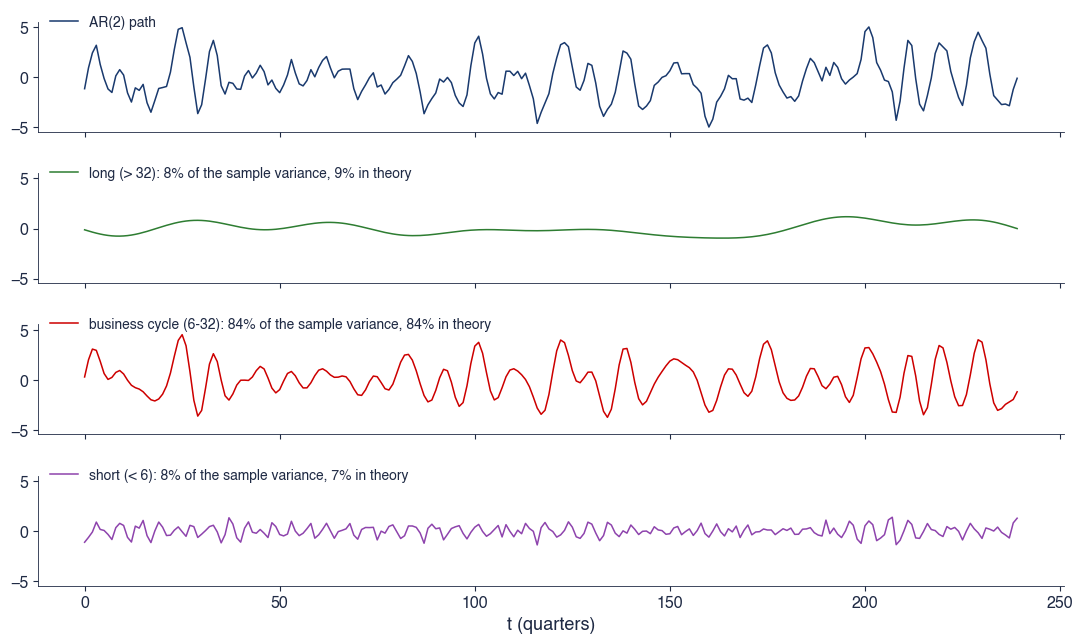

{'theory': {'long (> 32)': 0.08686372716207531, 'business cycle (6-32)': 0.8385633138106863, 'short (< 6)': 0.07456138484936312}, 'sample': {'long (> 32)': 0.08403106782437653, 'business cycle (6-32)': 0.8372059313467811, 'short (< 6)': 0.07876300082884204}, 'peak': 9.503433649713132, 'n': 240, 'g0': 4.722220232785434}


In [7]:
def fig_bands(save_it=True, n=240):
    """An AR(2) path split by FFT into long (> 32), business-cycle (6-32) and short (< 6) components; the variance
    shares 2 int_band f / gamma(0) of the spectrum against the shares in the sample."""
    rng = np.random.default_rng(SEED)
    x = simulate_arma(n, ar=AR2, rng=rng)
    X = np.fft.rfft(x - x.mean())
    per = np.r_[np.inf, n / np.arange(1, len(X))]
    bands = {'long (> 32)': per > 32, 'business cycle (6-32)': (per >= 6) & (per <= 32), 'short (< 6)': per < 6}
    comp = {k: np.fft.irfft(X * m, n) for k, m in bands.items()}
    om = np.linspace(1e-6, np.pi, 200001)
    f = arma_spectrum(om, ar=AR2)
    g0 = 2 * np.trapezoid(f, om)
    th = {'long (> 32)': (0, 2 * np.pi / 32), 'business cycle (6-32)': (2 * np.pi / 32, 2 * np.pi / 6),
          'short (< 6)': (2 * np.pi / 6, np.pi)}
    share_th = {k: float(2 * np.trapezoid(f[(om >= a) & (om <= b)], om[(om >= a) & (om <= b)]) / g0) for k, (a, b) in th.items()}
    share_s = {k: float(np.var(v) / np.var(x)) for k, v in comp.items()}
    fig, axs = plt.subplots(4, 1, figsize=(11, 6.6), sharex=True)
    axs[0].plot(x, color=st.MainBlue, lw=1.1, label='AR(2) path')
    for ax, (k, v), c in zip(axs[1:], comp.items(), [st.Forest, st.IDAred, st.Purple]):
        ax.plot(v, color=c, lw=1.1, label=f'{k}: {100 * share_s[k]:.0f}% of the sample variance, {100 * share_th[k]:.0f}% in theory')
        ax.set_ylim(axs[0].get_ylim())
    for ax in axs:
        ax.legend(loc='upper left', frameon=False, fontsize=10, bbox_to_anchor=(0, 1.18))
    axs[-1].set_xlabel('t (quarters)')
    plt.tight_layout(h_pad=1.4)
    save('ats_ch11_bands', save_it)
    peak = float(2 * np.pi / om[np.argmax(f)])
    return dict(theory=share_th, sample=share_s, peak=peak, n=n, g0=float(g0))


print(fig_bands(save_it=False))

## 2. Lag windows and the bias-variance trade-off

- 100 simulations here (400 on the slides).

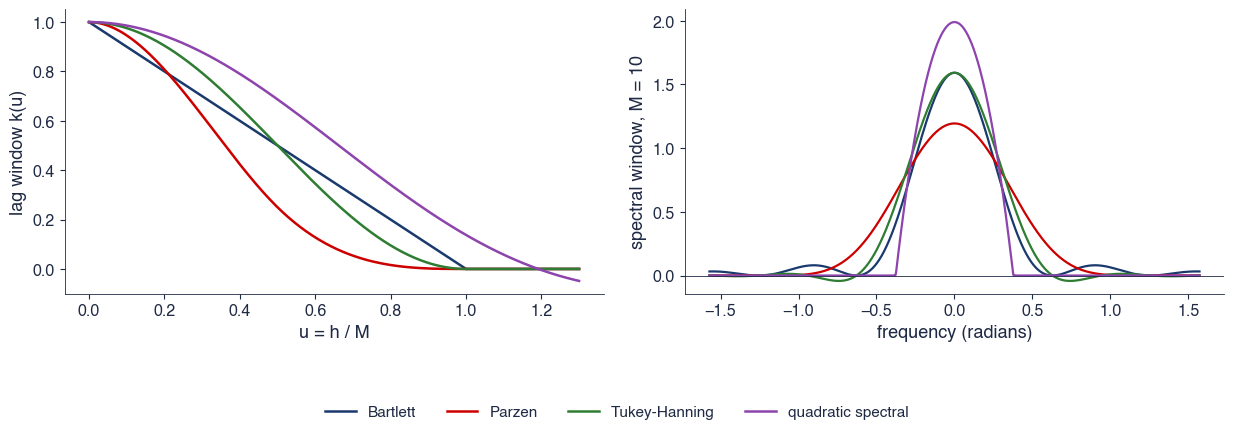

{'bartlett': {'q': 1.0, 'kq': 1.0, 'k2': 0.6666666666666666, 'w0': 1.5915494309189535, 'wmin': -3.533949646070574e-17}, 'parzen': {'q': 2.0, 'kq': 6.0, 'k2': 0.539285, 'w0': 1.193662073189215, 'wmin': 1.766974823035287e-17}, 'tukey': {'q': 2.0, 'kq': 2.4674011002723395, 'k2': 0.75, 'w0': 1.5915494309189537, 'wmin': -0.042460072721034754}, 'qs': {'q': 2.0, 'kq': 1.421223, 'k2': 1.0, 'w0': 1.989458550442277, 'wmin': -0.0026512778748970928}}


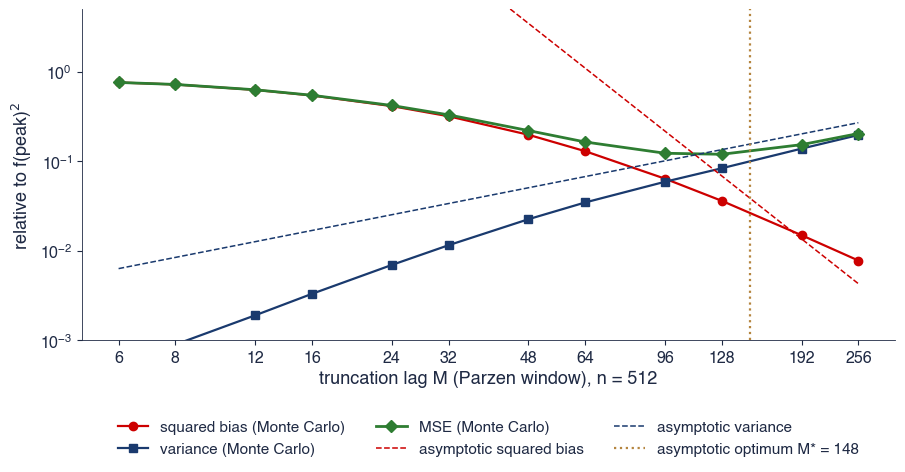

{'M_mc': 128, 'M_th': 147.5511906513355, 'peak_period': 11.115674429319556, 'rmse_opt': 0.3459091658096578, 'rmse_12': 0.7930626671504112, 'rmse_96': 0.3505446469674953, 'bias_12': 0.7918631942256705, 'sd_96': 0.2429726523961546, 'reps': 100, 'n': 512}


In [8]:
def fig_kernels(save_it=True, M=10):
    """Lag windows k(u) and the corresponding spectral windows W_M(w) = (2 pi)^-1 sum_{|h| < M'} k(h/M) exp(-i w h)."""
    u = np.linspace(0, 1.3, 400)
    om = np.linspace(-np.pi / 2, np.pi / 2, 801)
    names = {'bartlett': 'Bartlett', 'parzen': 'Parzen', 'tukey': 'Tukey-Hanning', 'qs': 'quadratic spectral'}
    cols = [st.MainBlue, st.IDAred, st.Forest, st.Purple]
    fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.0))
    out = {}
    for (k, lab), c in zip(names.items(), cols):
        axs[0].plot(u, kernel(u, k), color=c, lw=1.8, label=lab)
        h = np.arange(1, 400)
        w = (1 + 2 * (kernel(h / M, k)[:, None] * np.cos(np.outer(h, om))).sum(axis=0)) / (2 * np.pi)
        axs[1].plot(om, w, color=c, lw=1.6)
        out[k] = dict(q=KERNEL_CONST[k][0], kq=KERNEL_CONST[k][1], k2=KERNEL_CONST[k][2],
                      w0=float(w[np.argmin(np.abs(om))]), wmin=float(w.min()))
    axs[0].set_xlabel('u = h / M')
    axs[0].set_ylabel('lag window k(u)')
    axs[1].set_xlabel('frequency (radians)')
    axs[1].set_ylabel(f'spectral window, M = {M}')
    axs[1].axhline(0, color=st.DarkText, lw=0.6)
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch11_kernels', save_it)
    return out


def fig_bias_variance(save_it=True, n=512, reps=400, Ms=(6, 8, 12, 16, 24, 32, 48, 64, 96, 128, 192, 256)):
    """Parzen lag-window estimator at the peak of an AR(2) spectrum: Monte Carlo bias^2, variance and MSE against M,
    and the asymptotic approximations bias = -(k_2 / M^2) f^(2)(w), variance = (M / n) f(w)^2 int k^2."""
    rng = np.random.default_rng(SEED)
    om = np.linspace(1e-4, np.pi, 20001)
    f = arma_spectrum(om, ar=AR2_SHARP)
    wp = float(om[np.argmax(f)])
    fp = float(arma_spectrum([wp], ar=AR2_SHARP)[0])
    # f^(2)(w) = (2 pi)^-1 sum_h h^2 gamma(h) e^{-i w h}: gamma from the inverse transform of the spectrum
    H = 400
    g = np.array([2 * np.trapezoid(f * np.cos(h * om), om) for h in range(H)])
    f2 = float((0 * g[0] + 2 * np.sum(np.arange(1, H) ** 2 * g[1:] * np.cos(wp * np.arange(1, H)))) / (2 * np.pi))
    est = np.zeros((reps, len(Ms)))
    for r in range(reps):
        x = simulate_arma(n, ar=AR2_SHARP, rng=rng)
        for i, M in enumerate(Ms):
            est[r, i] = lag_window(x, M, 'parzen', omega=[wp])[1][0]
    bias2 = (est.mean(axis=0) - fp) ** 2
    var = est.var(axis=0)
    mse = bias2 + var
    q, kq, k2 = KERNEL_CONST['parzen']
    Mg = np.linspace(Ms[0], Ms[-1], 300)
    b_as = (kq * f2 / Mg ** 2) ** 2
    v_as = Mg / n * fp ** 2 * k2
    M_th = float((4 * kq ** 2 * f2 ** 2 * n / (fp ** 2 * k2)) ** 0.2)
    fig, ax = plt.subplots(figsize=(10.5, 4.3))
    ax.plot(Ms, bias2 / fp ** 2, 'o-', color=st.IDAred, lw=1.6, label='squared bias (Monte Carlo)')
    ax.plot(Ms, var / fp ** 2, 's-', color=st.MainBlue, lw=1.6, label='variance (Monte Carlo)')
    ax.plot(Ms, mse / fp ** 2, 'D-', color=st.Forest, lw=2, label='MSE (Monte Carlo)')
    ax.plot(Mg, b_as / fp ** 2, '--', color=st.IDAred, lw=1.1, label='asymptotic squared bias')
    ax.plot(Mg, v_as / fp ** 2, '--', color=st.MainBlue, lw=1.1, label='asymptotic variance')
    ax.axvline(M_th, color=st.Amber, ls=':', lw=1.6, label=f'asymptotic optimum M* = {M_th:.0f}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks(Ms)
    ax.set_xticklabels([str(m) for m in Ms])
    ax.minorticks_off()
    ax.set_ylim(1e-3, 5)
    ax.set_xlabel('truncation lag M (Parzen window), n = 512')
    ax.set_ylabel('relative to f(peak)$^2$')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    save('ats_ch11_bias_variance', save_it)
    i = int(np.argmin(mse))
    return dict(M_mc=int(Ms[i]), M_th=M_th, peak_period=2 * np.pi / wp, rmse_opt=float(np.sqrt(mse[i]) / fp),
                rmse_12=float(np.sqrt(mse[Ms.index(12)]) / fp), rmse_96=float(np.sqrt(mse[Ms.index(96)]) / fp),
                bias_12=float(np.sqrt(bias2[Ms.index(12)]) / fp), sd_96=float(np.sqrt(var[Ms.index(96)]) / fp), reps=reps, n=n)


print(fig_kernels(save_it=False))
print(fig_bias_variance(save_it=False, reps=100))

## 3. Slepian tapers, leakage and multitaper

- 50 and 100 simulations here (200 and 400 on the slides).

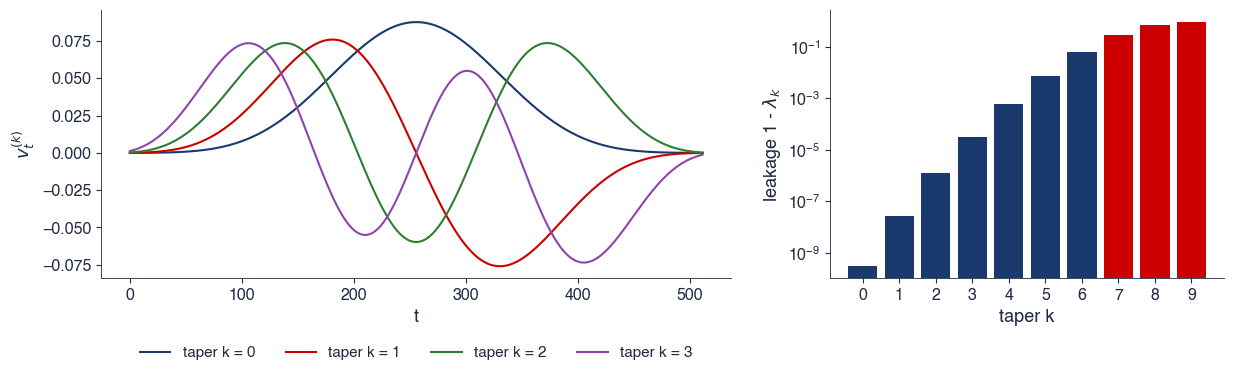

{'lam': [0.9999999997060645, 0.9999999723665247, 0.9999987915370874, 0.9999675878086994, 0.9994104943163835, 0.9925077219167562, 0.9366649347333353, 0.6988487680342248, 0.29936327890639125, 0.06422880073655897], 'n': 512, 'NW': 4}


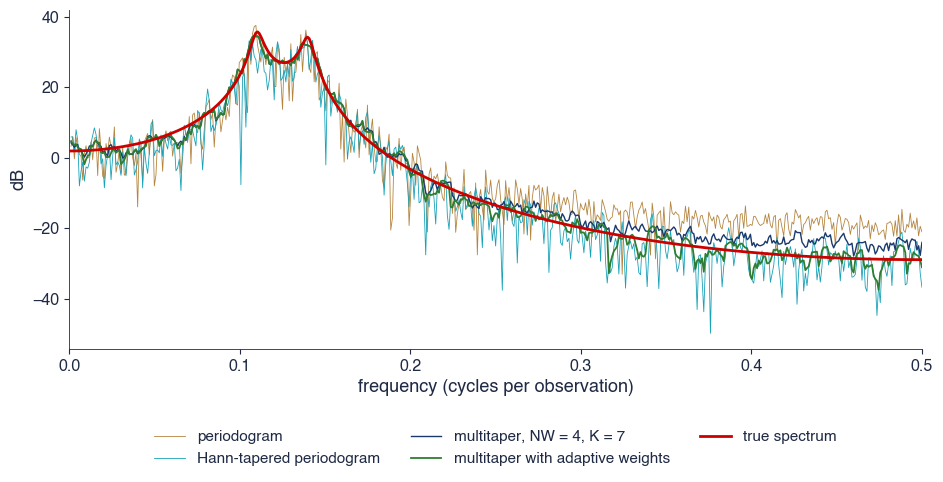

{'range_db': 64.63447695160369, 'bias_raw': 12.322520271418982, 'bias_hann': -2.4866378877602284, 'bias_mt': 6.728833988321029, 'bias_mta': -0.7974713015441847, 'reps': 50, 'n': 1024}


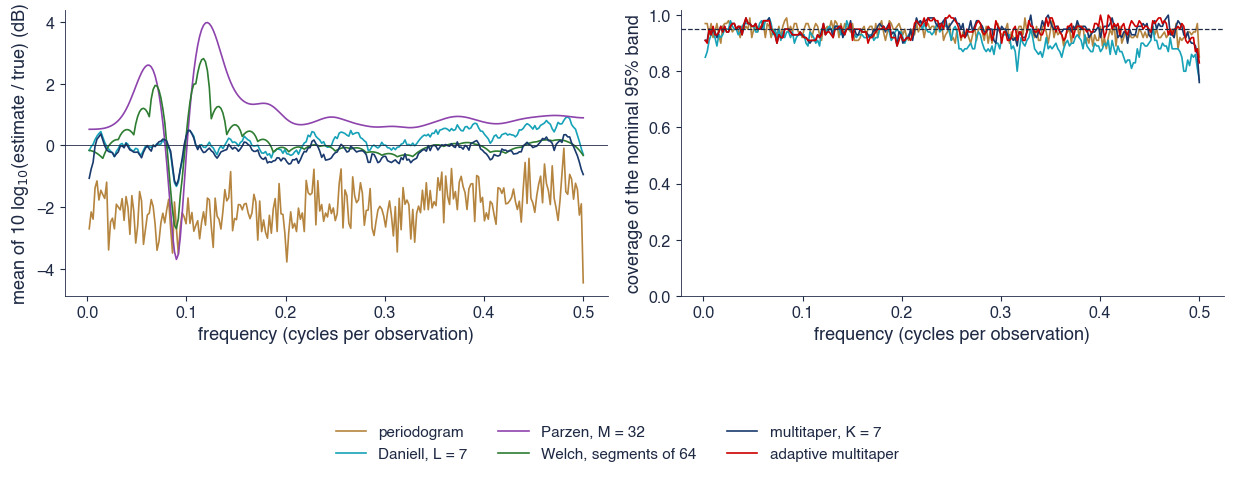

{'periodogram': {'bias_all': -2.0146367398807383, 'bias_peak': -2.564266700273432, 'sd': 5.481252913146478, 'cov_all': 0.9406640625, 'cov_peak': 0.955}, 'Daniell, L = 7': {'bias_all': 0.15693835025806172, 'bias_peak': -0.6050101378053193, 'sd': 1.7694816140377645, 'cov_all': 0.91203125, 'cov_peak': 0.928}, 'Parzen, M = 32': {'bias_all': 0.9920034706132228, 'bias_peak': -2.388337385036208, 'sd': 0.8511781897843325}, 'Welch, segments of 64': {'bias_all': 0.15193267362926044, 'bias_peak': -1.4712466983783228, 'sd': 1.0361660883982657}, 'multitaper, K = 7': {'bias_all': -0.1857980265649079, 'bias_peak': -0.5328881104762069, 'sd': 1.6790739219869082, 'cov_all': 0.9465234375, 'cov_peak': 0.937}, 'adaptive multitaper': {'cov_all': 0.9471875, 'cov_peak': 0.938}, 'reps': 100, 'n': 512}


In [9]:
def fig_dpss(save_it=True, n=512, NW=4, K=10):
    """The first four Slepian tapers and the concentration ratios lambda_k: about 2NW - 1 tapers are well concentrated."""
    v, lam = dpss(n, NW, K)
    fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.0), gridspec_kw=dict(width_ratios=[1.6, 1]))
    for k, c in zip(range(4), [st.MainBlue, st.IDAred, st.Forest, st.Purple]):
        axs[0].plot(v[k], color=c, lw=1.5, label=f'taper k = {k}')
    axs[0].set_xlabel('t')
    axs[0].set_ylabel('$v_t^{(k)}$')
    axs[1].bar(np.arange(K), 1 - lam, color=[st.MainBlue if k < 2 * NW - 1 else st.IDAred for k in range(K)])
    axs[1].set_yscale('log')
    axs[1].set_xlabel('taper k')
    axs[1].set_ylabel('leakage 1 - $\\lambda_k$')
    axs[1].set_xticks(range(K))
    st.legend_outside_bottom(axs[0], ncol=4, y=-0.2)
    plt.tight_layout()
    save('ats_ch11_dpss', save_it)
    return dict(lam=lam.tolist(), n=n, NW=NW)


def fig_leakage(save_it=True, n=1024, reps=200):
    """The AR(4) of Percival and Walden: true spectrum, raw periodogram, Hann-tapered periodogram and multitaper
    (NW = 4, K = 7) for one path; Monte Carlo mean bias in dB at high frequencies (0.3-0.5 cycles)."""
    rng = np.random.default_rng(SEED)
    w = 2 * np.pi * np.arange(1, n // 2 + 1) / n
    hi0 = w / (2 * np.pi) >= 0.3
    trh = arma_spectrum(w[hi0], ar=PW_AR4)
    paths = [simulate_arma(n, ar=PW_AR4, rng=rng) for _ in range(21)]       # show the path with the median leakage
    lk = [np.mean(10 * np.log10(periodogram(p)[1][hi0] / trh)) for p in paths]
    x = paths[int(np.argsort(lk)[10])]
    w, I = periodogram(x)
    _, Ih = periodogram(x, np.hanning(n))
    mt = multitaper(x, 4)
    mta = multitaper(x, 4, adaptive=True)
    tr = arma_spectrum(w, ar=PW_AR4)
    nu = w / (2 * np.pi)
    db = lambda v: 10 * np.log10(v)
    fig, ax = plt.subplots(figsize=(11, 4.4))
    ax.plot(nu, db(I), color=st.Amber, lw=0.6, label='periodogram')
    ax.plot(nu, db(Ih), color=st.Teal, lw=0.6, label='Hann-tapered periodogram')
    ax.plot(nu, db(mt['f']), color=st.MainBlue, lw=1.0, label='multitaper, NW = 4, K = 7')
    ax.plot(nu, db(mta['f']), color=st.Forest, lw=1.3, label='multitaper with adaptive weights')
    ax.plot(nu, db(tr), color=st.IDAred, lw=2, label='true spectrum')
    ax.set_xlabel('frequency (cycles per observation)')
    ax.set_ylabel('dB')
    ax.set_xlim(0, 0.5)
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    save('ats_ch11_leakage', save_it)
    hi = nu >= 0.3
    B = {'raw': [], 'hann': [], 'mt': [], 'mta': []}
    for _ in range(reps):
        y = simulate_arma(n, ar=PW_AR4, rng=rng)
        B['raw'].append(np.mean(db(periodogram(y)[1][hi] / tr[hi])))
        B['hann'].append(np.mean(db(periodogram(y, np.hanning(n))[1][hi] / tr[hi])))
        B['mt'].append(np.mean(db(multitaper(y, 4)['f'][hi] / tr[hi])))
        B['mta'].append(np.mean(db(multitaper(y, 4, adaptive=True)['f'][hi] / tr[hi])))
    return dict(range_db=float(db(tr.max() / tr.min())), bias_raw=float(np.mean(B['raw'])),
                bias_hann=float(np.mean(B['hann'])), bias_mt=float(np.mean(B['mt'])), bias_mta=float(np.mean(B['mta'])), reps=reps, n=n)


def fig_mt_mc(save_it=True, n=512, reps=400):
    """Monte Carlo on the sharp AR(2) (peak near 11 periods): mean bias (dB) of five estimators across frequencies and
    the coverage of the nominal 95% chi-square bands of the periodogram (2 df), Daniell (2L df), multitaper (2K df)
    and adaptive multitaper (its equivalent degrees of freedom)."""
    rng = np.random.default_rng(SEED + 1)
    w = 2 * np.pi * np.arange(1, n // 2 + 1) / n
    tr = arma_spectrum(w, ar=AR2_SHARP)
    m, M, nseg, NW = 3, 32, 64, 4
    acc = {k: [] for k in ('periodogram', 'Daniell, L = 7', 'Parzen, M = 32', 'Welch, segments of 64', 'multitaper, K = 7')}
    cov = {k: [] for k in ('periodogram', 'Daniell, L = 7', 'multitaper, K = 7', 'adaptive multitaper')}
    for _ in range(reps):
        x = simulate_arma(n, ar=AR2_SHARP, rng=rng)
        I = periodogram(x)[1]
        Dn = daniell(x, m)[1]
        Pz = lag_window(x, M, 'parzen', omega=w)[1]
        ww, We = welch(x, nseg)
        We = np.interp(w, ww, We)
        mt = multitaper(x, NW)
        mta = multitaper(x, NW, adaptive=True)
        for k, v in zip(acc, (I, Dn, Pz, We, mt['f'])):
            acc[k].append(10 * np.log10(np.maximum(v, 1e-12) / tr))
        for k, v, d in (('periodogram', I, 2), ('Daniell, L = 7', Dn, 2 * (2 * m + 1))):
            cov[k].append((d * v / stats.chi2.ppf(0.975, d) <= tr) & (tr <= d * v / stats.chi2.ppf(0.025, d)))
        cov['multitaper, K = 7'].append((mt['lo'] <= tr) & (tr <= mt['hi']))
        cov['adaptive multitaper'].append((mta['lo'] <= tr) & (tr <= mta['hi']))
    nu = w / (2 * np.pi)
    fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.2))
    cols = [st.Amber, st.Teal, st.Purple, st.Forest, st.MainBlue]
    for (k, v), c in zip(acc.items(), cols):
        axs[0].plot(nu, np.mean(v, axis=0), color=c, lw=1.2, label=k)
    axs[0].axhline(0, color=st.DarkText, lw=0.6)
    axs[0].set_xlabel('frequency (cycles per observation)')
    axs[0].set_ylabel('mean of 10 log$_{10}$(estimate / true) (dB)')
    for k, c in zip(cov, [st.Amber, st.Teal, st.MainBlue, st.IDAred]):
        axs[1].plot(nu, np.mean(cov[k], axis=0), color=c, lw=1.2, label=k if k == 'adaptive multitaper' else '_' + k)
    axs[1].axhline(0.95, color=st.DarkText, ls='--', lw=0.9)
    axs[1].set_xlabel('frequency (cycles per observation)')
    axs[1].set_ylabel('coverage of the nominal 95% band')
    axs[1].set_ylim(0, 1.02)
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.12, 1, 1))
    save('ats_ch11_mt_mc', save_it)
    peak = np.abs(nu - 1 / 11.1) < 0.01
    out = {k: dict(bias_all=float(np.mean(v)), bias_peak=float(np.mean(np.array(v)[:, peak])),
                   sd=float(np.mean(np.std(v, axis=0)))) for k, v in acc.items()}
    for k, v in cov.items():
        out.setdefault(k, {}).update(cov_all=float(np.mean(v)), cov_peak=float(np.mean(np.array(v)[:, peak])))
    out['reps'] = reps
    out['n'] = n
    return out


print(fig_dpss(save_it=False))
print(fig_leakage(save_it=False, reps=50))
print(fig_mt_mc(save_it=False, reps=100))

## 4. Industrial production: spectra and the harmonic F test

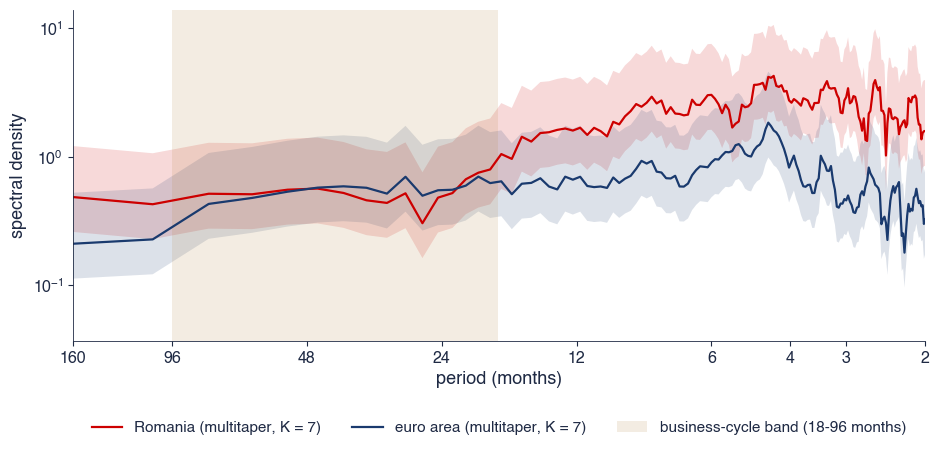

{'RO': {'n': 318, 'start': '2000-02-01', 'end': '2026-07-01', 'sd': 3.6124283278860507, 'share_bc': 0.02121114323228227, 'share_short': 0.768910281059862, 'dof': 14.0}, 'EA20': {'n': 318, 'start': '2000-02-01', 'end': '2026-07-01', 'sd': 1.982695638099076, 'share_bc': 0.07342978510576383, 'share_short': 0.6883810180732711, 'dof': 14.0}}


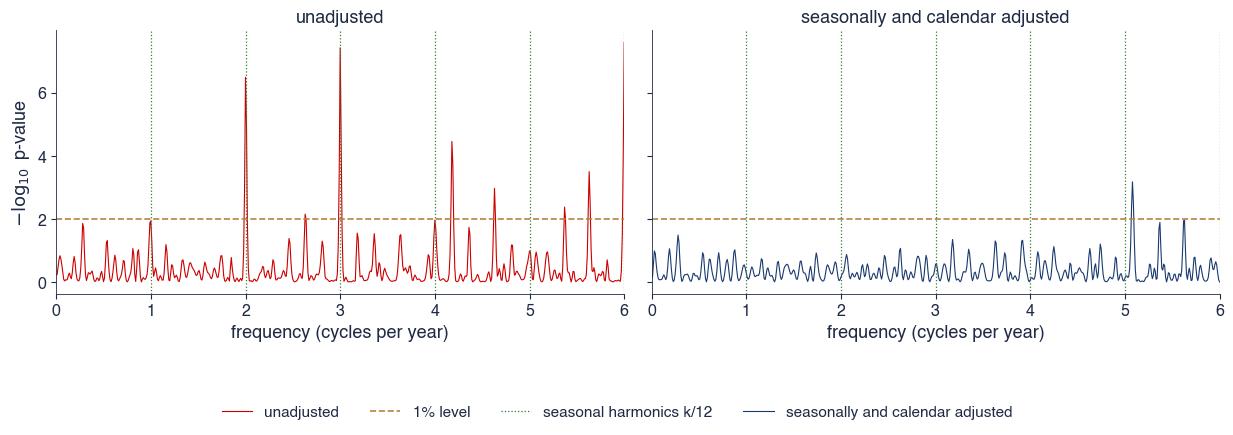

{'NSA': {'p': [0.011828718178932647, 3.255386616424154e-07, 3.7739226170479374e-08, 0.011046666022907617, 0.10481642342512724, 2.566160653470482e-08], 'n_sig': 3, 'n': 318, 'K': 7, 'n_other': 10, 'n_freq': 600, 'p_td': 3.537144778768139e-05}, 'SCA': {'p': [0.5137577815301468, 0.7112573077014905, 0.2783394625418019, 0.8735279094465376, 0.7753458072713886, 0.9974522405836148], 'n_sig': 0, 'n': 318, 'K': 7, 'n_other': 0, 'n_freq': 600, 'p_td': 0.21526219756809037}}


In [10]:
def fig_ip_spectrum(save_it=True, NW=4):
    """Multitaper spectra (95% bands) of monthly industrial production growth, Romania and the euro area."""
    out = {}
    fig, ax = plt.subplots(figsize=(11, 4.3))
    for geo in ('RO', 'EA20'):
        y = ip_growth(geo)
        mt = multitaper(y.values, NW)
        per = 2 * np.pi / mt['w']
        ax.plot(per, mt['f'], color=GEO_COL[geo], lw=1.6, label=f'{GEO_LAB[geo]} (multitaper, K = {mt["K"]})')
        ax.fill_between(per, mt['lo'], mt['hi'], color=GEO_COL[geo], alpha=0.15, lw=0, label=f'_95% band {geo}')
        bc = (per >= BC_M[0]) & (per <= BC_M[1])
        out[geo] = dict(n=len(y), start=str(y.index[0].date()), end=str(y.index[-1].date()), sd=float(y.std()),
                        share_bc=float(mt['f'][bc].sum() / mt['f'].sum()), share_short=float(mt['f'][per < 6].sum() / mt['f'].sum()),
                        dof=float(mt['dof'][0]))
    shade_band(ax, *BC_M, label='business-cycle band (18-96 months)')
    ax.set_yscale('log')
    per_axis(ax, 2, 160, [2, 3, 4, 6, 12, 24, 48, 96, 160], 'period (months)')
    ax.set_ylabel('spectral density')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    save('ats_ch11_ip_spectrum', save_it)
    return out


def fig_ftest(save_it=True, NW=4, nfft=1200):
    """Thomson's harmonic F test on Romanian industrial production growth, unadjusted and seasonally adjusted:
    p-values by frequency (cycles per year) with the six seasonal harmonics k/12 marked."""
    out = {}
    fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.0), sharey=True)
    for ax, adj, lab in zip(axs, ('NSA', 'SCA'), ('unadjusted', 'seasonally and calendar adjusted')):
        y = ip_growth('RO', adj)
        r = harmonic_ftest(y.values, NW, nfft=nfft)
        cpy = 12 * r['w'] / (2 * np.pi)
        lp = -np.log10(r['p'])
        ax.plot(cpy, lp, color=st.MainBlue if adj == 'SCA' else st.IDAred, lw=0.8, label=f'{lab}')
        ax.axhline(-np.log10(0.01), color=st.Amber, ls='--', lw=1.2, label='1% level')
        for k in range(1, 7):
            ax.axvline(k, color=st.Forest, ls=':', lw=0.9, label='seasonal harmonics k/12' if k == 1 else '_h')
        hits = []
        for k in range(1, 7):
            i = int(np.argmin(np.abs(cpy - k)))
            hits.append(float(r['p'][i]))
        out[adj] = dict(p=hits, n_sig=int(sum(p < 0.01 for p in hits)), n=len(y), K=r['K'],
                        n_other=int(((r['p'] < 0.01) & (np.min(np.abs(cpy[:, None] - np.arange(1, 7)[None, :]), axis=1) > 0.1)).sum()),
                        n_freq=int(len(cpy)),
                        p_td=float(r['p'][(np.abs(cpy - 4.176) < 0.05)].min()))   # trading-day frequency 0.348 cycles per month
        ax.set_xlabel('frequency (cycles per year)')
        ax.set_xlim(0, 6)
        ax.set_title(lab)
    axs[0].set_ylabel('$-\\log_{10}$ p-value')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch11_ftest', save_it)
    return out


print(fig_ip_spectrum(save_it=False))
print(fig_ftest(save_it=False))

## 5. Coherence, phase, gain and dynamic correlation

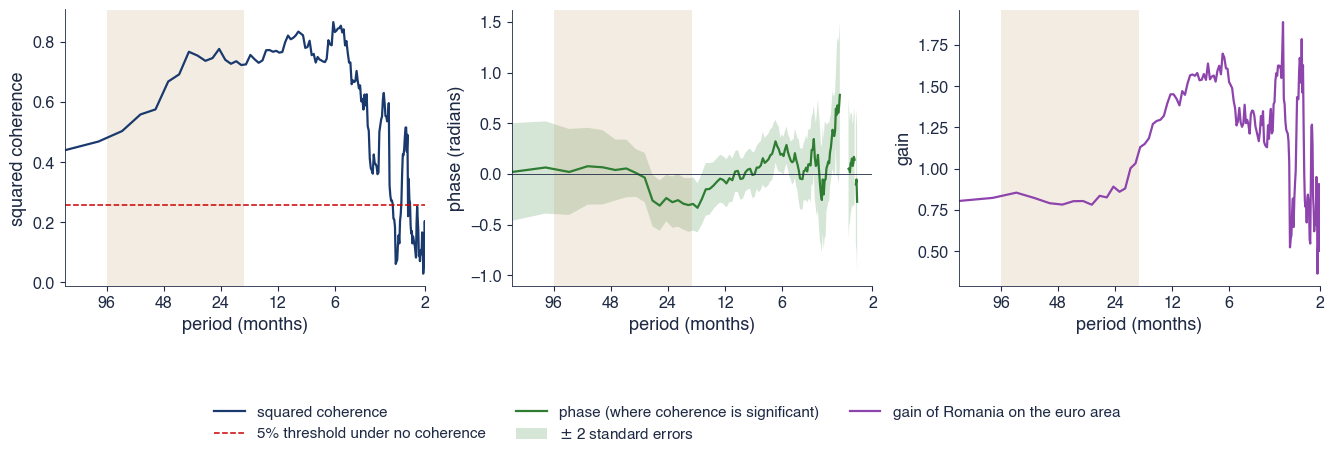

{'n': 318, 'start': '2000-02-01', 'end': '2026-07-01', 'K': 11, 'thr': 0.2588655508930522, 'coh_bc': 0.6926864541528485, 'coh_short': 0.4716771181701459, 'share_sig_bc': 1.0, 'share_sig_short': 0.706766917293233, 'lead_med': -0.5261829398755759, 'gain_bc': 0.8545194934761463, 'gain_short': 1.2400952891388493, 'corr': 0.6585946503924718}


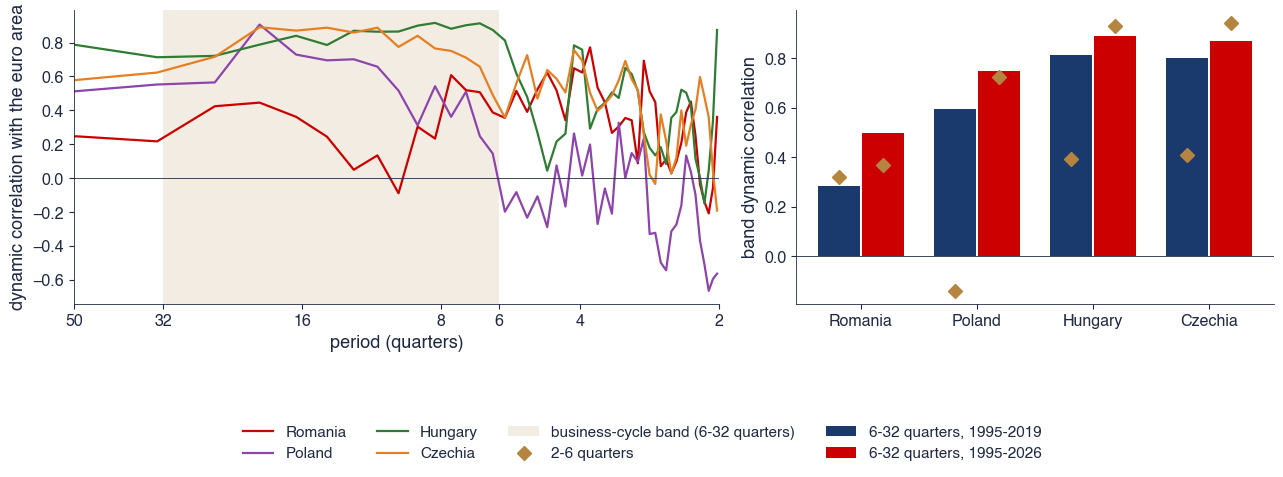

{'RO': {'pre': {'bc': 0.28330727185175686, 'short': 0.3207022929456694, 'corr': 0.2030395018721618, 'n': 99}, 'full': {'bc': 0.49822275214988454, 'short': 0.3675849391591105, 'corr': 0.3501057746651084, 'n': 125}}, 'PL': {'pre': {'bc': 0.5958499369396636, 'short': -0.14008124562602553, 'corr': 0.17762335357436393, 'n': 99}, 'full': {'bc': 0.7467749646624477, 'short': 0.7254847060034868, 'corr': 0.6910092312487424, 'n': 125}}, 'HU': {'pre': {'bc': 0.8146242401116984, 'short': 0.3939770220478241, 'corr': 0.6315049682051537, 'n': 99}, 'full': {'bc': 0.88974639139529, 'short': 0.9283533279177871, 'corr': 0.9059927646709748, 'n': 125}}, 'CZ': {'pre': {'bc': 0.8013943137954189, 'short': 0.410247029029053, 'corr': 0.6235840172169381, 'n': 99}, 'full': {'bc': 0.8691703942232872, 'short': 0.9428032224134271, 'corr': 0.8790037512113671, 'n': 125}}}


In [11]:
def fig_coherence(save_it=True, NW=6):
    """Romania and the euro area, monthly industrial production growth: squared coherence with its 5% null threshold,
    phase (positive: the euro area leads) with two-standard-error bands where coherence is significant, gain."""
    d = pd.concat([ip_growth('EA20'), ip_growth('RO')], axis=1, join='inner').dropna()
    cs = cross_spectrum(d['EA20'].values, d['RO'].values, NW)
    per = 2 * np.pi / cs['w']
    sig = cs['coh'] > cs['thr']
    fig, axs = plt.subplots(1, 3, figsize=(13.5, 4.0))
    axs[0].plot(per, cs['coh'], color=st.MainBlue, lw=1.6, label='squared coherence')
    axs[0].axhline(cs['thr'], color=st.IDAred, ls='--', lw=1.1, label='5% threshold under no coherence')
    axs[0].set_ylabel('squared coherence')
    ph = np.where(sig, cs['phase'], np.nan)
    axs[1].plot(per, ph, color=st.Forest, lw=1.6, label='phase (where coherence is significant)')
    axs[1].fill_between(per, ph - 2 * cs['se_phase'], ph + 2 * cs['se_phase'], color=st.Forest, alpha=0.2, lw=0,
                        label='$\\pm$ 2 standard errors')
    axs[1].axhline(0, color=st.DarkText, lw=0.6)
    axs[1].set_ylabel('phase (radians)')
    axs[2].plot(per, cs['gain'], color=st.Purple, lw=1.6, label='gain of Romania on the euro area')
    axs[2].set_ylabel('gain')
    for ax in axs:
        shade_band(ax, *BC_M, label='_bc')
        per_axis(ax, 2, 160, [2, 6, 12, 24, 48, 96], 'period (months)')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save('ats_ch11_coherence', save_it)
    bc = (per >= BC_M[0]) & (per <= BC_M[1])
    sh = per < 12
    lead = cs['phase'][bc & sig] / cs['w'][bc & sig]
    return dict(n=len(d), start=str(d.index[0].date()), end=str(d.index[-1].date()), K=cs['K'], thr=cs['thr'],
                coh_bc=float(cs['coh'][bc].mean()), coh_short=float(cs['coh'][sh].mean()),
                share_sig_bc=float(sig[bc].mean()), share_sig_short=float(sig[sh].mean()),
                lead_med=float(np.median(lead)) if len(lead) else float('nan'),
                gain_bc=float(cs['gain'][bc].mean()), gain_short=float(cs['gain'][sh].mean()),
                corr=float(np.corrcoef(d['EA20'], d['RO'])[0, 1]))


def fig_dyncorr(save_it=True, NW=3):
    """Dynamic correlation (Croux, Forni and Reichlin 2001) of quarterly GDP growth with the euro area: curves for the
    pre-COVID sample 1995Q2-2019Q4 and band averages (2-6 and 6-32 quarters) for the pre-COVID and the full sample."""
    out = {}
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw=dict(width_ratios=[1.35, 1]))
    for geo in CEE:
        o = {}
        for lab, end in (('pre', '2019-12-31'), ('full', '2026-06-30')):
            d = pd.concat([gdp_growth('EA20', end), gdp_growth(geo, end)], axis=1, join='inner').dropna()
            cs = cross_spectrum(d['EA20'].values, d[geo].values, NW)
            o[lab] = dict(bc=band_dyncorr(cs, 2 * np.pi / 32, 2 * np.pi / 6), short=band_dyncorr(cs, 2 * np.pi / 6, np.pi),
                          corr=float(np.corrcoef(d['EA20'], d[geo])[0, 1]), n=len(d))
            if lab == 'pre':
                per = 2 * np.pi / cs['w']
                axs[0].plot(per, cs['dyncorr'], color=GEO_COL[geo], lw=1.6, label=GEO_LAB[geo])
        out[geo] = o
    shade_band(axs[0], *BC_Q, label='business-cycle band (6-32 quarters)')
    axs[0].axhline(0, color=st.DarkText, lw=0.6)
    per_axis(axs[0], 2, 50, [2, 4, 6, 8, 16, 32, 50], 'period (quarters)')
    axs[0].set_ylabel('dynamic correlation with the euro area')
    xs = np.arange(len(CEE))
    for j, (lab, c, hatch) in enumerate((('pre', st.MainBlue, ''), ('full', st.IDAred, ''))):
        axs[1].bar(xs + (j - 0.5) * 0.38, [out[g][lab]['bc'] for g in CEE], 0.36, color=c,
                   label='6-32 quarters, ' + ('1995-2019' if lab == 'pre' else '1995-2026'))
        axs[1].plot(xs + (j - 0.5) * 0.38, [out[g][lab]['short'] for g in CEE], 'D', color=st.Amber, ms=7,
                    label='2-6 quarters' if j == 0 else '_s')
    axs[1].set_xticks(xs)
    axs[1].set_xticklabels([GEO_LAB[g] for g in CEE])
    axs[1].axhline(0, color=st.DarkText, lw=0.6)
    axs[1].set_ylabel('band dynamic correlation')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save('ats_ch11_dyncorr', save_it)
    return out


print(fig_coherence(save_it=False))
print(fig_dyncorr(save_it=False))

## 6. Granger causality by frequency

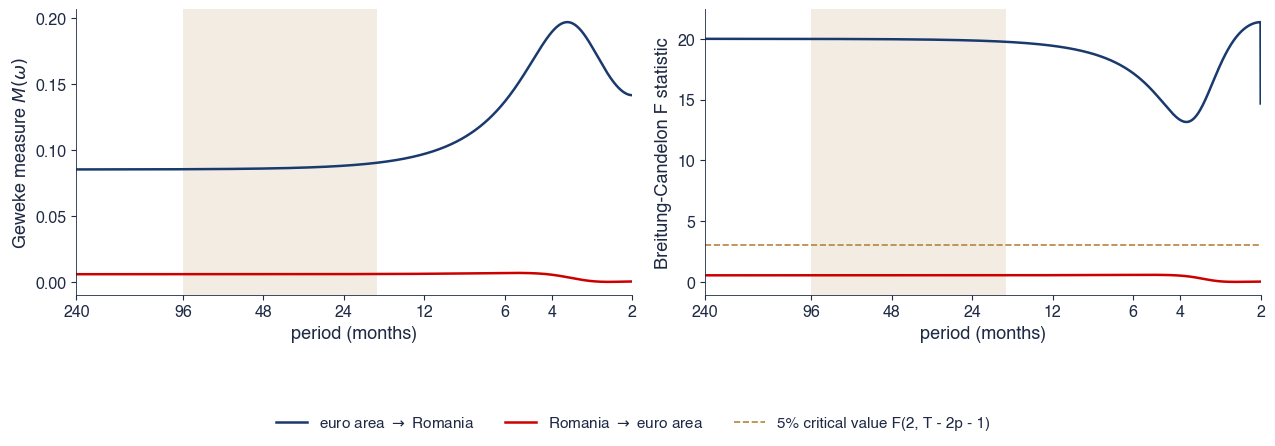

{'p': 3, 'n': 318, 'F_ea_ro': 0.1462269151693546, 'F_ro_ea': 0.003818223534123977, 'int_ea_ro': 0.1452905272704233, 'M_bc': 0.08724014523620341, 'M_short': 0.16818622316326987, 'M0': 0.0851883967671435, 'rej_min': 2.0, 'rej_max': 240.0, 'share_rej': 1.0, 'share_rej2': 0.0, 'share_rej_bc': 1.0, 'crit': 3.0250598334948906, 'Fmax': 21.365361256593637, 'per_Fmax': 2.0033165647078497}


In [12]:
def fig_causality(save_it=True, pmax=12, pmin=3):
    """Euro area and Romania, monthly industrial production growth: Geweke (1982) measures in both directions and the
    Breitung-Candelon (2006) F statistic across frequencies, VAR order by AIC (at least 3, so that the frequency
    restrictions are not equivalent to the full Granger test)."""
    d = pd.concat([ip_growth('EA20'), ip_growth('RO')], axis=1, join='inner').dropna()
    Y = d[['RO', 'EA20']].values                       # series 0 = Romania, series 1 = euro area
    p, _ = var_order(Y, pmax, 'aic')
    p = max(p, pmin)
    om = np.linspace(2 * np.pi / 240, np.pi, 600)
    g = geweke(Y, p, om)
    bc1 = breitung_candelon(Y, p, om, cause=1, target=0)   # EA -> RO
    bc2 = breitung_candelon(Y, p, om, cause=0, target=1)   # RO -> EA
    per = 2 * np.pi / om
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.1))
    axs[0].plot(per, g['1->0'], color=st.MainBlue, lw=1.8, label='euro area $\\to$ Romania')
    axs[0].plot(per, g['0->1'], color=st.IDAred, lw=1.8, label='Romania $\\to$ euro area')
    axs[0].set_ylabel('Geweke measure $M(\\omega)$')
    axs[1].plot(per, bc1['F'], color=st.MainBlue, lw=1.8)
    axs[1].plot(per, bc2['F'], color=st.IDAred, lw=1.8)
    axs[1].axhline(bc1['crit'], color=st.Amber, ls='--', lw=1.2, label='5% critical value F(2, T - 2p - 1)')
    axs[1].set_ylabel('Breitung-Candelon F statistic')
    for ax in axs:
        shade_band(ax, *BC_M, label='_bc')
        per_axis(ax, 2, 240, [2, 4, 6, 12, 24, 48, 96, 240], 'period (months)')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save('ats_ch11_causality', save_it)
    rej = per[bc1['p'] < 0.05]
    rej2 = per[bc2['p'] < 0.05]
    bc = (per >= BC_M[0]) & (per <= BC_M[1])
    return dict(p=int(p), n=len(d), F_ea_ro=g['F1->0'], F_ro_ea=g['F0->1'],
                int_ea_ro=float(np.trapezoid(g['1->0'], om) / np.pi), M_bc=float(g['1->0'][bc].mean()),
                M_short=float(g['1->0'][per < 6].mean()), M0=float(g['1->0'][0]),
                rej_min=float(rej.min()) if len(rej) else None, rej_max=float(rej.max()) if len(rej) else None,
                share_rej=float((bc1['p'] < 0.05).mean()), share_rej2=float((bc2['p'] < 0.05).mean()),
                share_rej_bc=float((bc1['p'][bc] < 0.05).mean()), crit=bc1['crit'],
                Fmax=float(bc1['F'].max()), per_Fmax=float(per[np.argmax(bc1['F'])]))


print(fig_causality(save_it=False))

## 7. Filters: gains, the spurious HP cycle, Romanian cycles, real time, synchronisation

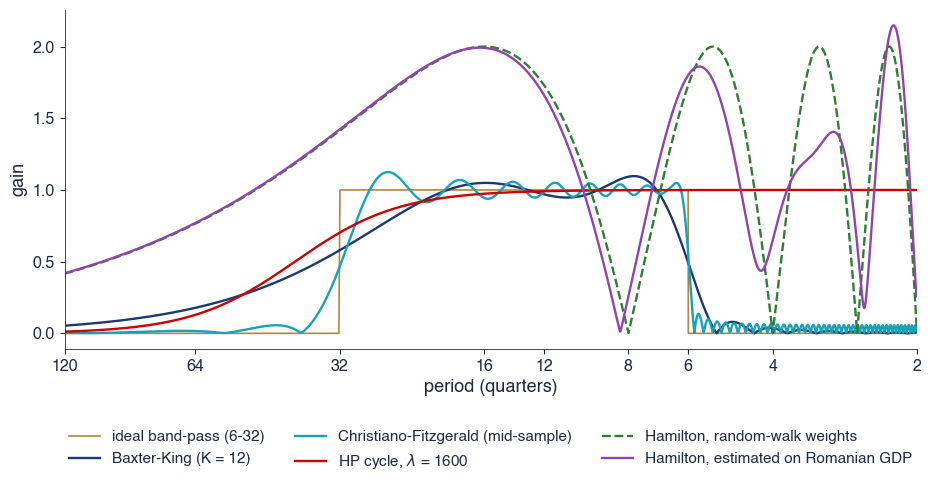

{'hp32': 0.7026377208875577, 'hp40': 0.4924147361701564, 'hp60': 0.16113081969636245, 'hp6': 0.9993753898475031, 'bk_peak': 1.0967197840448004, 'bk_40': 0.40950528299269373, 'bk_4': 0.037241340579387605, 'ham16': 1.999995929085534, 'ham8': 0.003853379591359945, 'ham_e16': 1.9914981633792712, 'ham_e8': 0.2567188740085858, 'ham_b': [35.637374241474994, 0.7616047698334565, 0.061272549887881625, 0.35370767598013997, -0.20535242324627256], 'bk_a0': 0.2776648491533467, 'bk_sum': 6.765421556309548e-17}


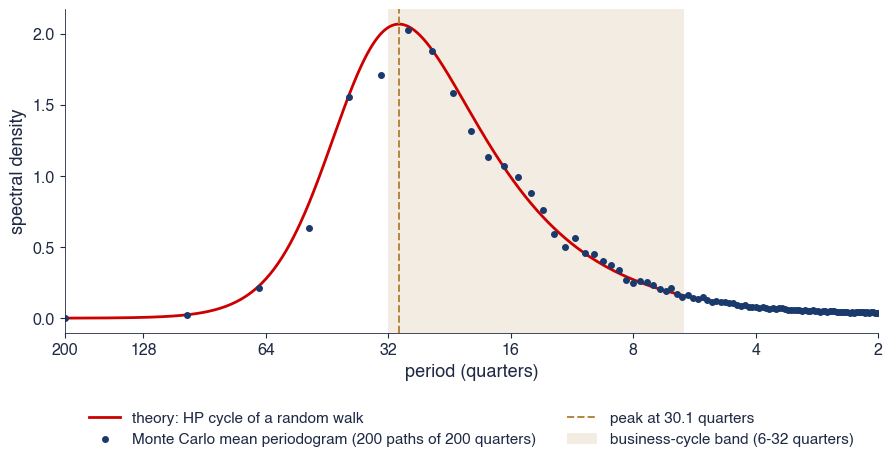

{'p_th': 30.13997299495647, 'p_mc': 28.57142857142857, 'n': 200, 'reps': 200, 'u': 0.021650635094610966}


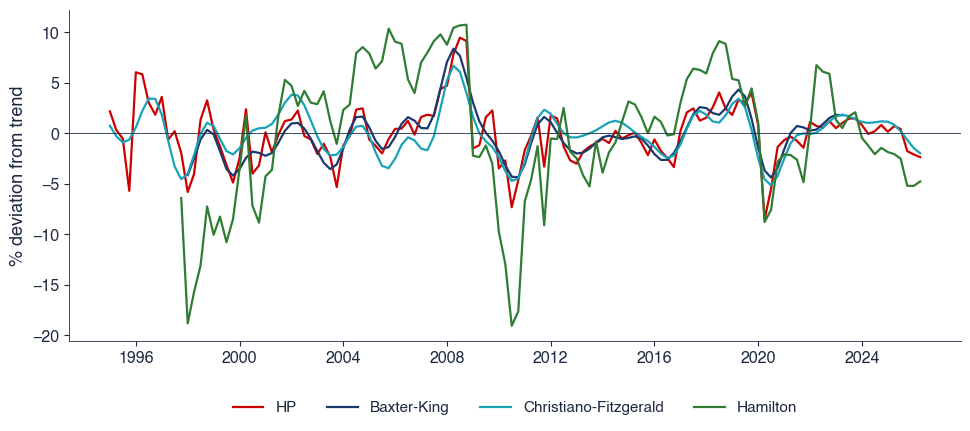

{'sd': {'HP': 2.8625036055498976, 'Baxter-King': 2.4991549474212817, 'Christiano-Fitzgerald': 2.183274825254295, 'Hamilton': 6.5717167894506305}, 'corr': {'HP|Hamilton': 0.6897174936558269, 'Baxter-King|HP': 0.8386237610725302, 'Baxter-King|Christiano-Fitzgerald': 0.8383832019541283, 'Baxter-King|Hamilton': 0.6452634054738587, 'Christiano-Fitzgerald|HP': 0.7364931270584385, 'Christiano-Fitzgerald|Hamilton': 0.48624595366269907}, 'last': {'HP': -2.3585348108197195, 'Baxter-King': 1.7817364260075075, 'Christiano-Fitzgerald': -1.9752053781465513, 'Hamilton': -4.766072820169029}, 'last_q': {'HP': '2026Q2', 'Baxter-King': '2023Q2', 'Christiano-Fitzgerald': '2026Q2', 'Hamilton': '2026Q2'}, 'min09': {'HP': -7.32015937313713, 'Baxter-King': -4.354871469870343, 'Christiano-Fitzgerald': -4.715341046130302, 'Hamilton': -19.048937699309135}, 'minq09': {'HP': '2010Q3', 'Baxter-King': '2010Q4', 'Christiano-Fitzgerald': '2010Q3', 'Hamilton': '2010Q3'}, 'max08': {'HP': 9.464614457766402, 'Baxter-King'

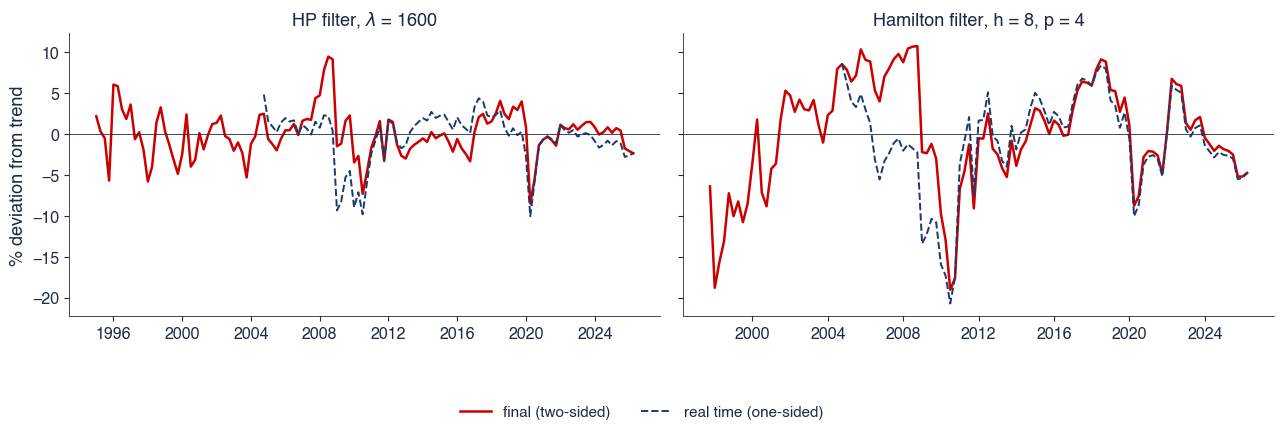

{'rms_hp': 2.8037450329737656, 'rms_ham': 4.630391720966825, 'corr_hp': 0.5691524005366222, 'corr_ham': 0.7563417000151899, 'sign_hp': 0.3793103448275862, 'sign_ham': 0.2413793103448276, 'sd_hp': 2.832577178747549, 'sd_ham': 6.15125486596925, 'n': 87, 'start': '2004Q4'}


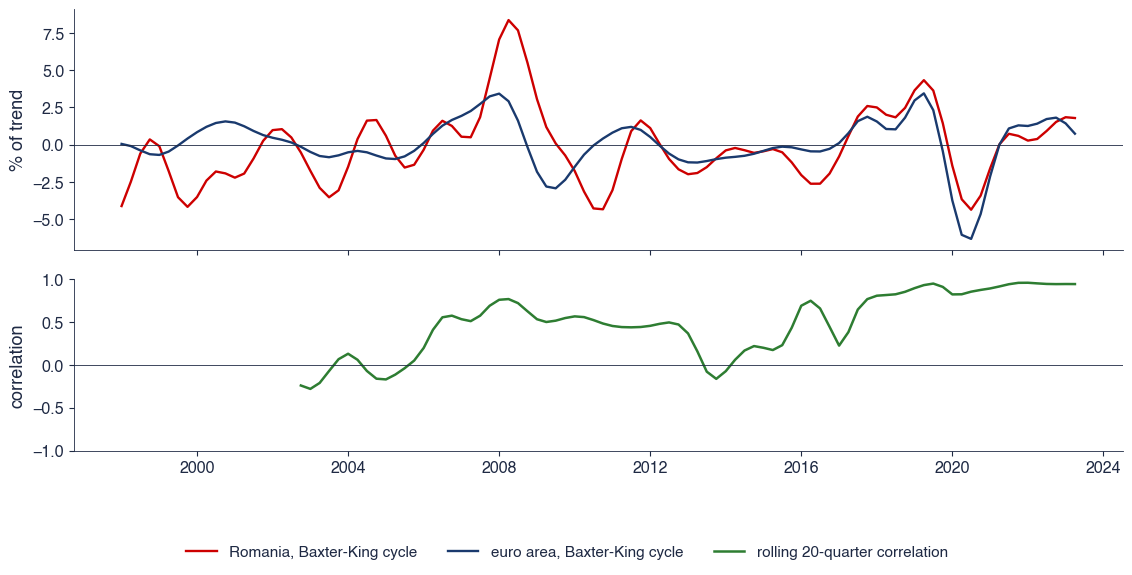

{'corr': 0.5364385180475061, 'c_pre': 0.34492267161099266, 'c_gfc': 0.46697513517930617, 'c_post': 0.8953328511507448, 'c_cov': 0.9589371294742008, 'conc': 0.7450980392156863, 'conc0': 0.5015378700499807, 'roll_min': -0.28201717910524954, 'roll_min_q': '2003Q1', 'start': '1998Q1', 'end': '2023Q2', 'sd_ro': 2.4991549474212817, 'sd_ea': 1.692036845918817}


In [13]:
def cf_central_weights(n=126, low=6, high=32):
    """Weights of the Christiano-Fitzgerald random-walk filter at the middle of a sample of n quarters, obtained by
    filtering unit vectors (the filter is linear but asymmetric and time-varying)."""
    from statsmodels.tsa.filters.cf_filter import cffilter
    E = np.eye(n)
    Wm = np.column_stack([cffilter(E[:, j], low, high, drift=False)[0] for j in range(n)])
    return Wm[n // 2], Wm


def fig_gains(save_it=True):
    """Gains (level to cycle) of the ideal band-pass filter, Baxter-King (6, 32, K = 12), Christiano-Fitzgerald (middle
    of a 126-quarter sample), HP (lambda = 1600) and Hamilton (h = 8, p = 4: random-walk weights and the weights
    estimated on Romanian GDP)."""
    om = np.linspace(2 * np.pi / 120, np.pi, 3000)
    per = 2 * np.pi / om
    a = bk_weights(6, 32, 12)
    wcf, _ = cf_central_weights()
    n = len(wcf)
    lags = n // 2 - np.arange(n)          # y_t weight index j -> lag (t_mid - j)
    _, b = hamilton_filter(gdp('RO').values, 8, 4)
    curves = {'ideal band-pass (6-32)': ideal_gain(om), 'Baxter-King (K = 12)': filter_gain(a, om),
              'Christiano-Fitzgerald (mid-sample)': np.abs(np.exp(-1j * np.outer(om, lags)) @ wcf),
              'HP cycle, $\\lambda$ = 1600': hp_gain(om, 1600), 'Hamilton, random-walk weights': hamilton_gain(om, [1, 0, 0, 0]),
              'Hamilton, estimated on Romanian GDP': hamilton_gain(om, b[1:])}
    cols = [st.Amber, st.MainBlue, st.Teal, st.IDAred, st.Forest, st.Purple]
    sty = ['-', '-', '-', '-', '--', '-']
    fig, ax = plt.subplots(figsize=(11, 4.4))
    for (k, v), c, s in zip(curves.items(), cols, sty):
        ax.plot(per, v, color=c, ls=s, lw=1.7 if k.startswith('ideal') is False else 1.2, label=k)
    per_axis(ax, 2, 120, [2, 4, 6, 8, 12, 16, 32, 64, 120], 'period (quarters)')
    ax.set_ylabel('gain')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    save('ats_ch11_gains', save_it)
    at = lambda v, P: float(np.interp(P, per[::-1], v[::-1]))
    hg = curves['Hamilton, random-walk weights']
    he = curves['Hamilton, estimated on Romanian GDP']
    return dict(hp32=at(curves['HP cycle, $\\lambda$ = 1600'], 32), hp40=at(curves['HP cycle, $\\lambda$ = 1600'], 40),
                hp60=at(curves['HP cycle, $\\lambda$ = 1600'], 60), hp6=at(curves['HP cycle, $\\lambda$ = 1600'], 6),
                bk_peak=float(filter_gain(a, om).max()), bk_40=at(curves['Baxter-King (K = 12)'], 40),
                bk_4=at(curves['Baxter-King (K = 12)'], 4), ham16=at(hg, 16), ham8=at(hg, 8), ham_e16=at(he, 16),
                ham_e8=at(he, 8), ham_b=b.tolist(), bk_a0=float(a[12]), bk_sum=float(a.sum()))


def fig_cogley_nason(save_it=True, n=200, reps=500):
    """The HP cycle of a random walk: theoretical spectrum H(w)^2 / (2 (1 - cos w)) (Cogley and Nason 1995) and the
    Monte Carlo average periodogram of HP-filtered random walks (n = 200 quarters)."""
    rng = np.random.default_rng(SEED)
    om = np.linspace(2 * np.pi / 200, np.pi, 4000)
    th = hp_gain(om) ** 2 / (2 * (1 - np.cos(om))) / (2 * np.pi)
    P = []
    for _ in range(reps):
        c, _ = hp_filter(np.cumsum(rng.standard_normal(n)))
        P.append(periodogram(c)[1])
    w = 2 * np.pi * np.arange(1, n // 2 + 1) / n
    Pm = np.mean(P, axis=0)
    u = np.sqrt(3 / (4 * 1600))
    p_th = 2 * np.pi / np.arccos(1 - u)
    fig, ax = plt.subplots(figsize=(10.5, 4.2))
    ax.plot(2 * np.pi / om, th, color=st.IDAred, lw=2, label='theory: HP cycle of a random walk')
    ax.plot(2 * np.pi / w, Pm, 'o', color=st.MainBlue, ms=4, label=f'Monte Carlo mean periodogram ({reps} paths of {n} quarters)')
    ax.axvline(p_th, color=st.Amber, ls='--', lw=1.4, label=f'peak at {p_th:.1f} quarters')
    shade_band(ax, *BC_Q, label='business-cycle band (6-32 quarters)')
    per_axis(ax, 2, 200, [2, 4, 8, 16, 32, 64, 128, 200], 'period (quarters)')
    ax.set_ylabel('spectral density')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    save('ats_ch11_cogley_nason', save_it)
    i = np.argmax(Pm)
    return dict(p_th=float(p_th), p_mc=float(2 * np.pi / w[i]), n=n, reps=reps, u=float(u))


def ro_cycles():
    from statsmodels.tsa.filters.cf_filter import cffilter
    y = gdp('RO')
    c = pd.DataFrame(index=y.index)
    c['HP'] = hp_filter(y.values, 1600)[0]
    c['Baxter-King'] = bk_filter(y.values, 6, 32, 12)
    c['Christiano-Fitzgerald'] = cffilter(y.values, 6, 32, drift=True)[0]
    c['Hamilton'] = hamilton_filter(y.values, 8, 4)[0]
    return y, c


def fig_ro_cycles(save_it=True):
    """Romanian real GDP, 1995Q1-2026Q2: cycles (in % of trend) of HP, Baxter-King, Christiano-Fitzgerald and Hamilton."""
    y, c = ro_cycles()
    fig, ax = plt.subplots(figsize=(11.5, 4.3))
    for k, col in zip(c.columns, [st.IDAred, st.MainBlue, st.Teal, st.Forest]):
        ax.plot(c.index, c[k], color=col, lw=1.6, label=k)
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_ylabel('% deviation from trend')
    st.legend_outside_bottom(ax, ncol=4, y=-0.14)
    save('ats_ch11_ro_cycles', save_it)
    cc = c.dropna()
    q = lambda d: f'{d.year}Q{(d.month - 1) // 3 + 1}'
    return dict(sd={k: float(c[k].std()) for k in c}, corr={f'{a}|{b}': float(cc[a].corr(cc[b])) for a in c for b in c if a < b},
                last={k: float(c[k].dropna().iloc[-1]) for k in c}, last_q={k: q(c[k].dropna().index[-1]) for k in c},
                min09={k: float(c[k].loc['2008-01-01':'2011-12-31'].min()) for k in c},
                minq09={k: q(c[k].loc['2008-01-01':'2011-12-31'].idxmin()) for k in c},
                max08={k: float(c[k].loc['2006-01-01':'2009-12-31'].max()) for k in c},
                start=q(y.index[0]), end=q(y.index[-1]), n=len(y))


def fig_endpoint(save_it=True, start=40):
    """Real-time (one-sided) and final (two-sided) HP cycles of Romanian GDP, and the real-time Hamilton cycle (the
    regression re-estimated on the data available at each date) against its final version."""
    y = gdp('RO')
    Yv = y.values
    hp_final = hp_filter(Yv, 1600)[0]
    hp_rt = hp_one_sided(Yv, 1600, start)
    ham_final = hamilton_filter(Yv, 8, 4)[0]
    ham_rt = np.full(len(Yv), np.nan)
    for t in range(start, len(Yv) + 1):
        ham_rt[t - 1] = hamilton_filter(Yv[:t], 8, 4)[0][-1]
    df = pd.DataFrame(dict(hp_final=hp_final, hp_rt=hp_rt, ham_final=ham_final, ham_rt=ham_rt), index=y.index)
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.0), sharey=True)
    axs[0].plot(df.index, df['hp_final'], color=st.IDAred, lw=1.8, label='final (two-sided)')
    axs[0].plot(df.index, df['hp_rt'], color=st.MainBlue, lw=1.4, ls='--', label='real time (one-sided)')
    axs[0].set_title('HP filter, $\\lambda$ = 1600')
    axs[1].plot(df.index, df['ham_final'], color=st.IDAred, lw=1.8)
    axs[1].plot(df.index, df['ham_rt'], color=st.MainBlue, lw=1.4, ls='--')
    axs[1].set_title('Hamilton filter, h = 8, p = 4')
    for ax in axs:
        ax.axhline(0, color=st.DarkText, lw=0.6)
    axs[0].set_ylabel('% deviation from trend')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch11_endpoint', save_it)
    d = df.dropna()
    r = lambda a, b: float(np.sqrt(np.mean((d[a] - d[b]) ** 2)))
    return dict(rms_hp=r('hp_final', 'hp_rt'), rms_ham=r('ham_final', 'ham_rt'),
                corr_hp=float(d['hp_final'].corr(d['hp_rt'])), corr_ham=float(d['ham_final'].corr(d['ham_rt'])),
                sign_hp=float((np.sign(d['hp_final']) != np.sign(d['hp_rt'])).mean()),
                sign_ham=float((np.sign(d['ham_final']) != np.sign(d['ham_rt'])).mean()),
                sd_hp=float(d['hp_final'].std()), sd_ham=float(d['ham_final'].std()), n=len(d),
                start=f'{d.index[0].year}Q{(d.index[0].month - 1) // 3 + 1}')


def fig_sync(save_it=True, win=20):
    """Baxter-King cycles of Romania and the euro area and their rolling 20-quarter correlation; Harding-Pagan
    concordance of the phases."""
    c = pd.DataFrame({g: bk_filter(gdp(g).values, 6, 32, 12) for g in ('RO', 'EA20')}, index=gdp('RO').index).dropna()
    roll = c['RO'].rolling(win).corr(c['EA20'])
    fig, axs = plt.subplots(2, 1, figsize=(11.5, 5.4), sharex=True, gridspec_kw=dict(height_ratios=[1.4, 1]))
    axs[0].plot(c.index, c['RO'], color=st.IDAred, lw=1.7, label='Romania, Baxter-King cycle')
    axs[0].plot(c.index, c['EA20'], color=st.MainBlue, lw=1.7, label='euro area, Baxter-King cycle')
    axs[0].axhline(0, color=st.DarkText, lw=0.6)
    axs[0].set_ylabel('% of trend')
    axs[1].plot(roll.index, roll, color=st.Forest, lw=1.8, label=f'rolling {win}-quarter correlation')
    axs[1].axhline(0, color=st.DarkText, lw=0.6)
    axs[1].set_ylim(-1, 1)
    axs[1].set_ylabel('correlation')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.07, 1, 1))
    save('ats_ch11_sync', save_it)
    sub = lambda a, b: float(c.loc[a:b, 'RO'].corr(c.loc[a:b, 'EA20']))
    C, C0 = concordance(c['RO'], c['EA20'])
    return dict(corr=float(c['RO'].corr(c['EA20'])), c_pre=sub('1995-01-01', '2007-12-31'), c_gfc=sub('2008-01-01', '2012-12-31'),
                c_post=sub('2013-01-01', '2019-12-31'), c_cov=sub('2020-01-01', '2026-12-31'), conc=C, conc0=C0,
                roll_min=float(roll.min()), roll_min_q=f'{roll.idxmin().year}Q{(roll.idxmin().month - 1) // 3 + 1}',
                start=f'{c.index[0].year}Q{(c.index[0].month - 1) // 3 + 1}', end=f'{c.index[-1].year}Q{(c.index[-1].month - 1) // 3 + 1}',
                sd_ro=float(c['RO'].std()), sd_ea=float(c['EA20'].std()))


print(fig_gains(save_it=False))
print(fig_cogley_nason(save_it=False, reps=200))
print(fig_ro_cycles(save_it=False))
print(fig_endpoint(save_it=False))
print(fig_sync(save_it=False))

## 8. A spectrum that changes over time

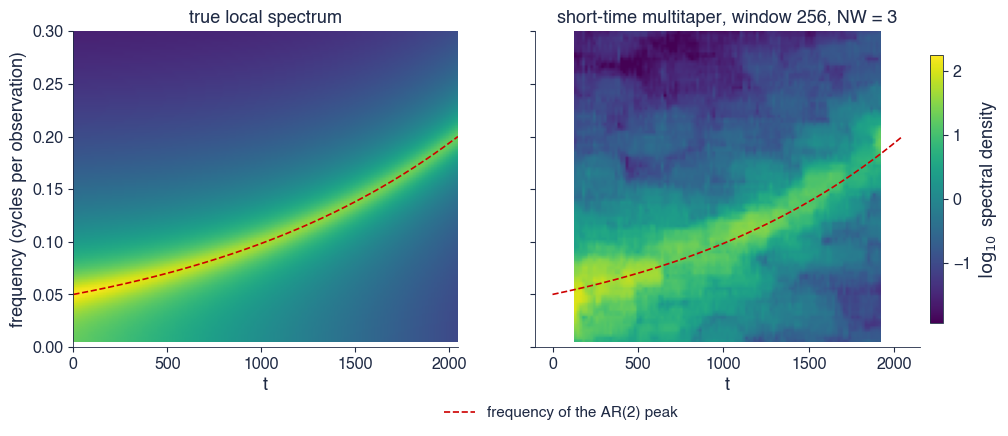

{'n': 2048, 'win': 256, 'NW': 3, 'res': 0.0234375, 'p0': 20.0, 'p1': 5.0}


In [14]:
def tvar2(n=2048, r=0.95, p0=20, p1=5, seed=SEED):
    """x_t = 2 r cos(theta_t) x_{t-1} - r^2 x_{t-2} + e_t with the peak period moving from p0 to p1 (log-linearly)."""
    rng = np.random.default_rng(seed)
    per = p0 * (p1 / p0) ** (np.arange(n) / (n - 1))
    th = 2 * np.pi / per
    x = np.zeros(n + 200)
    e = rng.standard_normal(n + 200)
    a1 = np.r_[np.full(200, 2 * r * np.cos(th[0])), 2 * r * np.cos(th)]
    for t in range(2, n + 200):
        x[t] = a1[t] * x[t - 1] - r ** 2 * x[t - 2] + e[t]
    return x[200:], a1[200:], per


def fig_spectrogram(save_it=True, n=2048, win=256, step=16, NW=3):
    """Time-varying AR(2): the true local spectrum f(u, w) and the short-time multitaper estimate (windows of 256)."""
    x, a1, per = tvar2(n)
    r = 0.95
    nu = np.linspace(0.005, 0.5, 200)
    true = np.array([arma_spectrum(2 * np.pi * nu, ar=(a, -r ** 2)) for a in a1[::step]]).T
    cent, est = [], []
    for s in range(0, n - win + 1, step):
        mt = multitaper(x[s:s + win], NW)
        est.append(np.interp(nu, mt['w'] / (2 * np.pi), mt['f']))
        cent.append(s + win // 2)
    est = np.array(est).T
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.1), sharey=True)
    vmin, vmax = np.log10(true).min(), np.log10(true).max()
    axs[0].imshow(np.log10(true), aspect='auto', origin='lower', extent=(0, n, nu[0], nu[-1]), cmap='viridis', vmin=vmin, vmax=vmax)
    im = axs[1].imshow(np.log10(est), aspect='auto', origin='lower', extent=(cent[0], cent[-1], nu[0], nu[-1]), cmap='viridis', vmin=vmin, vmax=vmax)
    axs[0].plot(np.arange(n), 1 / per, color=st.IDAred, lw=1.2, ls='--', label='frequency of the AR(2) peak')
    axs[1].plot(np.arange(n), 1 / per, color=st.IDAred, lw=1.2, ls='--')
    axs[0].set_title('true local spectrum')
    axs[1].set_title(f'short-time multitaper, window {win}, NW = {NW}')
    axs[0].set_ylabel('frequency (cycles per observation)')
    for ax in axs:
        ax.set_xlabel('t')
        ax.set_ylim(0, 0.3)
    cb = fig.colorbar(im, ax=axs, shrink=0.85, pad=0.01)
    cb.set_label('$\\log_{10}$ spectral density')
    st.fig_legend_bottom(fig, ncol=1, y=0.0)
    save('ats_ch11_spectrogram', save_it)
    return dict(n=n, win=win, NW=NW, res=2 * NW / win, p0=float(per[0]), p1=float(per[-1]))


print(fig_spectrogram(save_it=False))

## 9. Wavelets: MODWT, multiresolution, variance and correlation by scale

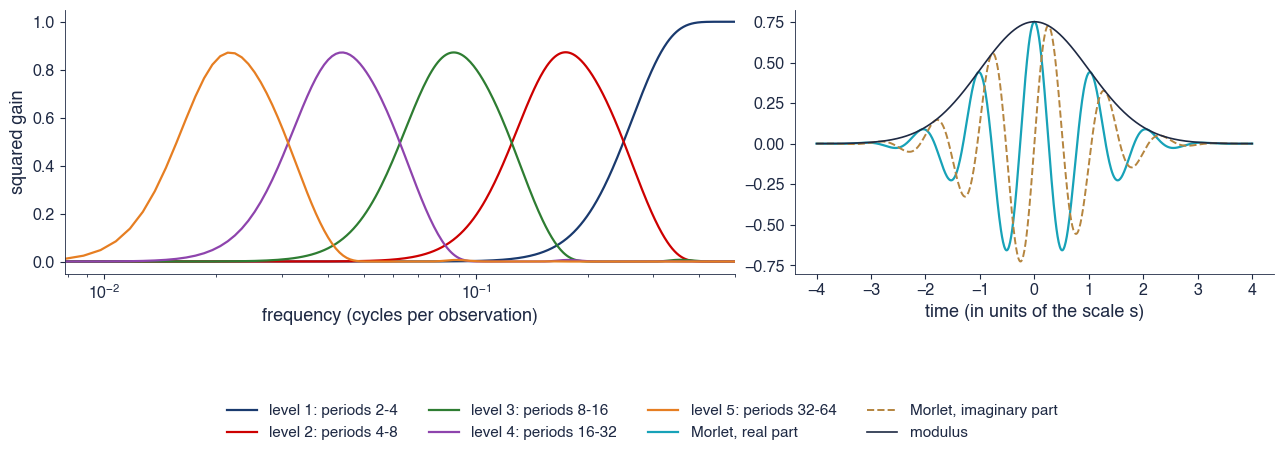

{'L': 8, 'sumg': 1.4142135623730947, 'sumh': -1.1314837955467283e-12}


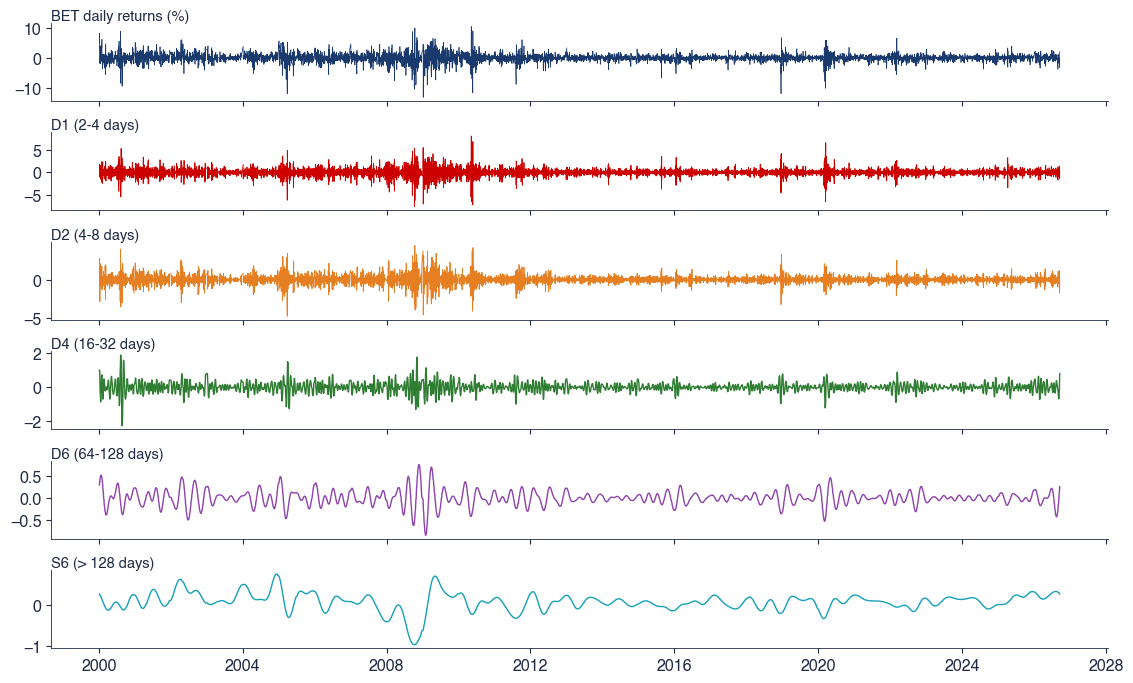

{'n': 6670, 'share': [0.43017435451028807, 0.26647127335834153, 0.14968372029102062, 0.06792205960866607, 0.03505231143288588, 0.02258250292913157], 'err': 1.503863700236252e-11, 'start': '2000-01-06', 'end': '2026-09-18'}


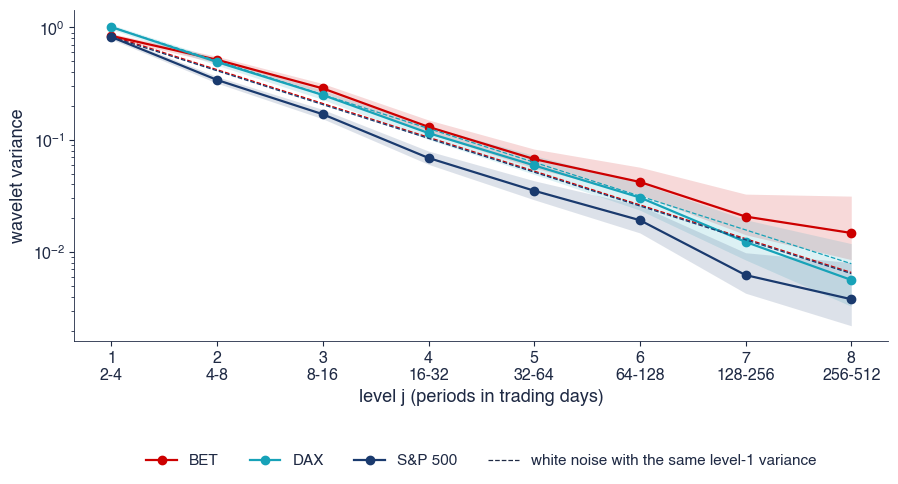

[1.0, 1.224898981678089, 1.3625800162086765, 1.2373436903973811, 1.2782770182852885, 1.5996855654334712, 1.5734251478965586, 2.2477104973545092]


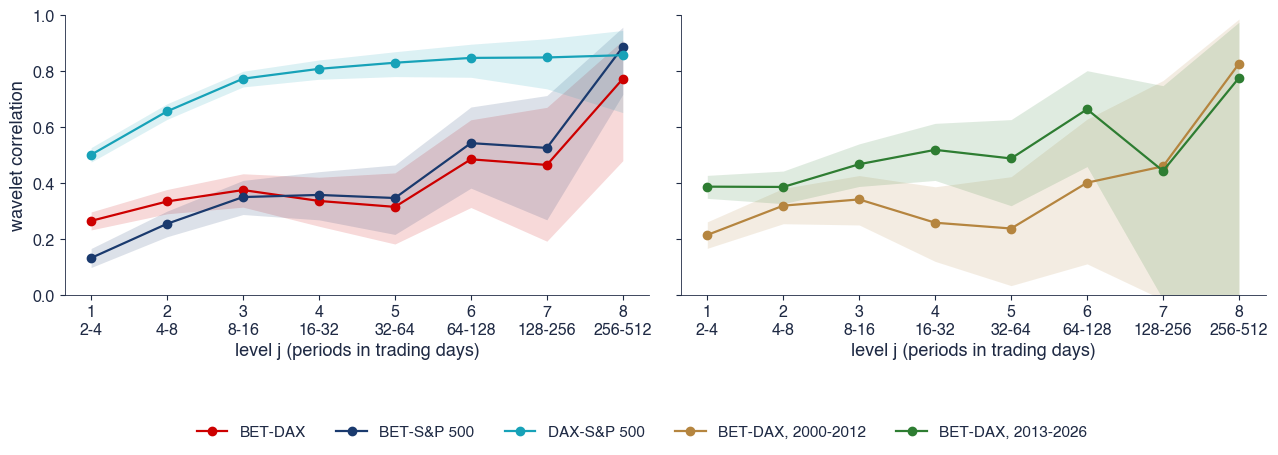

{'r': [0.2645277340360906, 0.3338852456025538, 0.37474272280924725, 0.3357873141352299, 0.31452516524349916, 0.4845857274626198, 0.4644352640662394, 0.7722537933642664], 'lo': [0.23207076589762066, 0.28966039991792, 0.3134949374354113, 0.2453010329735549, 0.18179092890496923, 0.3122849911428015, 0.1918503960505994, 0.4795829588867181], 'hi': [0.2963962963423951, 0.3766874602849295, 0.4328854563452649, 0.4204733752114553, 0.4360028720486587, 0.6260203611387346, 0.6704970647857657, 0.9103103725109087], 'beta': [0.2433256962514703, 0.33629497459511826, 0.39575999552425817, 0.348545042610934, 0.3391736100970204, 0.5635055571100568, 0.597075987679402, 1.2618410519785916], 'corr': 0.30939205777460443}


In [15]:
def fig_wavelets(save_it=True, J=5, n=1024):
    """Squared gains of the MODWT LA(8) level-j wavelet filters (octave bands [1/2^{j+1}, 1/2^j]) and the Morlet
    wavelet (w0 = 6) in time."""
    g, h = wavelet_filters('sym4')
    G = _transfer(g / np.sqrt(2), n)
    H = _transfer(h / np.sqrt(2), n)
    k = np.arange(n)
    f = k / n
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.0), gridspec_kw=dict(width_ratios=[1.4, 1]))
    Gp = np.ones(n, complex)
    cols = [st.MainBlue, st.IDAred, st.Forest, st.Purple, st.Orange]
    for j in range(1, J + 1):
        idx = (k * 2 ** (j - 1)) % n
        Hj = H[idx] * Gp
        Gp = Gp * G[idx]
        m = f <= 0.5
        axs[0].plot(f[m], np.abs(Hj[m]) ** 2, color=cols[j - 1], lw=1.6, label=f'level {j}: periods {2 ** j}-{2 ** (j + 1)}')
    axs[0].set_xscale('log')
    axs[0].set_xlim(1 / 128, 0.5)
    axs[0].set_xlabel('frequency (cycles per observation)')
    axs[0].set_ylabel('squared gain')
    t = np.linspace(-4, 4, 800)
    psi = np.pi ** -0.25 * np.exp(1j * 6 * t) * np.exp(-t ** 2 / 2)
    axs[1].plot(t, psi.real, color=st.Teal, lw=1.6, label='Morlet, real part')
    axs[1].plot(t, psi.imag, color=st.Amber, lw=1.4, ls='--', label='Morlet, imaginary part')
    axs[1].plot(t, np.abs(psi), color=st.DarkText, lw=1.2, label='modulus')
    axs[1].set_xlabel('time (in units of the scale s)')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.12, 1, 1))
    save('ats_ch11_wavelets', save_it)
    return dict(L=len(g), sumg=float(g.sum()), sumh=float(h.sum()))


def fig_mra(save_it=True, J=6):
    """MODWT multiresolution analysis (LA(8), J = 6) of the daily BET returns: details D1, D2, D4, D6 and smooth S6;
    energy share of each level (wavelet variance decomposition) against white noise."""
    y = bet_daily()
    D, S = mra(y.values, J)
    m = modwt(y.values, J)
    E = (y.values - y.values.mean()) ** 2
    share = [(m['W'][j] ** 2).sum() / ((m['W'] ** 2).sum() + (m['V'] ** 2).sum()) for j in range(J)]
    fig, axs = plt.subplots(6, 1, figsize=(11.5, 7.0), sharex=True)
    axs[0].plot(y.index, y.values, color=st.MainBlue, lw=0.5, label='BET daily returns (%)')
    for ax, (lab, v), c in zip(axs[1:], [('D1 (2-4 days)', D[0]), ('D2 (4-8 days)', D[1]), ('D4 (16-32 days)', D[3]),
                                         ('D6 (64-128 days)', D[5]), ('S6 (> 128 days)', S)],
                               [st.IDAred, st.Orange, st.Forest, st.Purple, st.Teal]):
        ax.plot(y.index, v, color=c, lw=0.6 if 'D1' in lab or 'D2' in lab else 1.0, label=lab)
    for ax in axs:
        ax.set_title(ax.get_lines()[0].get_label(), loc='left', fontsize=10.5, pad=2)
    plt.tight_layout(h_pad=0.6)
    save('ats_ch11_mra', save_it)
    return dict(n=len(y), share=[float(s) for s in share], err=float(np.abs(D.sum(0) + S - y.values).max()),
                start=str(y.index[0].date()), end=str(y.index[-1].date()))


def fig_wvar(save_it=True, J=8):
    """Wavelet variance by level of daily returns (BET, DAX, S&P 500) with 95% intervals; the dashed lines show
    white noise with the same level-1 variance (variance halving at each level)."""
    out = {}
    fig, ax = plt.subplots(figsize=(10.5, 4.3))
    for nm, lab in (('bet', 'BET'), ('dax', 'DAX'), ('sp500', 'S&P 500')):
        y = 100 * np.log(load_close(nm, start='2000-01-01', end=END)).diff().dropna()
        wv = wavelet_variance(y.values, J)
        lev = np.array([d['level'] for d in wv])
        v = np.array([d['var'] for d in wv])
        lo = np.array([d['lo'] for d in wv])
        hi = np.array([d['hi'] for d in wv])
        c = st.COL[nm]
        ax.plot(lev, v, 'o-', color=c, lw=1.6, label=lab)
        ax.fill_between(lev, lo, hi, color=c, alpha=0.15, lw=0)
        ax.plot(lev, v[0] / 2 ** (lev - 1), ls='--', color=c, lw=0.9, label=f'_wn {lab}')
        out[nm] = dict(var=v.tolist(), ratio=(v * 2 ** (lev - 1) / v[0]).tolist(), lo=lo.tolist(), hi=hi.tolist(), n=len(y))
    ax.set_yscale('log')
    ax.set_xticks(range(1, J + 1))
    ax.set_xticklabels([f'{j}\n{2 ** j}-{2 ** (j + 1)}' for j in range(1, J + 1)])
    ax.set_xlabel('level j (periods in trading days)')
    ax.set_ylabel('wavelet variance')
    ax.plot([], [], ls='--', color=st.DarkText, lw=0.9, label='white noise with the same level-1 variance')
    st.legend_outside_bottom(ax, ncol=4, y=-0.3)
    save('ats_ch11_wvar', save_it)
    return out


def fig_wcorr(save_it=True, J=8):
    """Wavelet correlation by level of daily returns on common trading days: BET-DAX, BET-S&P 500, DAX-S&P 500
    (left) and BET-DAX in 2000-2012 and 2013-2026 (right), 95% Fisher-z intervals; BET beta on the DAX by level."""
    R = daily_common(['bet', 'dax', 'sp500'])
    out = {}
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
    lev = np.arange(1, J + 1)
    for (a, b, lab, c) in (('bet', 'dax', 'BET-DAX', st.IDAred), ('bet', 'sp500', 'BET-S&P 500', st.MainBlue),
                           ('dax', 'sp500', 'DAX-S&P 500', st.Teal)):
        wc = wavelet_corr(R[b].values, R[a].values, J)
        r = np.array([d['r'] for d in wc])
        axs[0].plot(lev, r, 'o-', color=c, lw=1.6, label=lab)
        axs[0].fill_between(lev, [d['lo'] for d in wc], [d['hi'] for d in wc], color=c, alpha=0.15, lw=0)
        out[f'{a}_{b}'] = dict(r=r.tolist(), lo=[d['lo'] for d in wc], hi=[d['hi'] for d in wc], beta=[d['beta'] for d in wc],
                               corr=float(R[a].corr(R[b])))
    for (s, e, lab, c) in (('2000-01-01', '2012-12-31', 'BET-DAX, 2000-2012', st.Amber), ('2013-01-01', END, 'BET-DAX, 2013-2026', st.Forest)):
        Rs = R.loc[s:e]
        wc = wavelet_corr(Rs['dax'].values, Rs['bet'].values, J)
        r = np.array([d['r'] for d in wc])
        axs[1].plot(lev, r, 'o-', color=c, lw=1.6, label=lab)
        axs[1].fill_between(lev, [d['lo'] for d in wc], [d['hi'] for d in wc], color=c, alpha=0.15, lw=0)
        out['bet_dax_' + s[:4]] = dict(r=r.tolist(), lo=[d['lo'] for d in wc], hi=[d['hi'] for d in wc], n=len(Rs))
    for ax in axs:
        ax.set_xticks(lev)
        ax.set_xticklabels([f'{j}\n{2 ** j}-{2 ** (j + 1)}' for j in lev])
        ax.set_xlabel('level j (periods in trading days)')
        ax.set_ylim(0, 1)
    axs[0].set_ylabel('wavelet correlation')
    st.fig_legend_bottom(fig, ncol=5, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch11_wcorr', save_it)
    out['n'] = len(R)
    return out


print(fig_wavelets(save_it=False))
print(fig_mra(save_it=False))
print(fig_wvar(save_it=False)['bet']['ratio'])
print(fig_wcorr(save_it=False)['bet_dax'])

## 10. Wavelet power and wavelet coherence

- 200 Monte Carlo pairs here (500 on the slides).

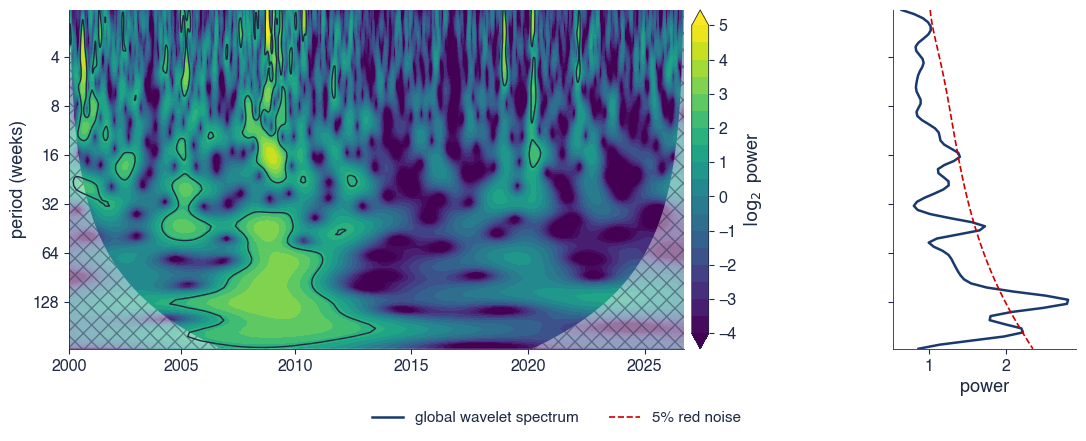

{'ar1': 0.03914343909539179, 'max_date': '2008-10-17', 'max_per': 2.6031068745189385, 'n': 1379, 'share_sig': 0.11429177268871926, 'share_sig_short': 0.06182015953589558, 'gws_peak': 124.80811046265804}


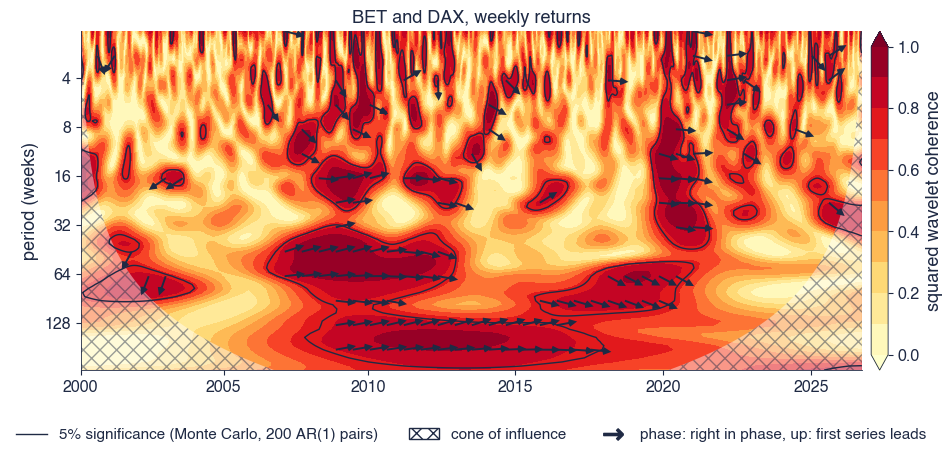

{'share_obs': 0.22608720795743698, 'null_mean': 0.04983735253296322, 'null_q95': 0.07425639987662885, 'null_max': 0.11805073637134705, 'ax': 0.03914343909539179, 'ay': -0.011383632605190097, 'n': 1379, 'reps': 200, 'null_any': 1.0, 'reps_check': 200, 'phase_sig': -0.1510181754041064, 'gfc': 0.7604265348032174, 'gfc_ph': 0.03228332098642349, 'calm': 0.35500342467447266, 'calm_ph': -0.46301267521508516, 'early': 0.37095801097545983, 'early_ph': -0.9679863265372658, 'covid': 0.7689728250686572, 'covid_ph': -0.16698850241624602, 'short_all': 0.436238214420004, 'short_all_ph': -0.3878147825646819, 'start': '2000-01-14', 'end': '2026-09-18'}


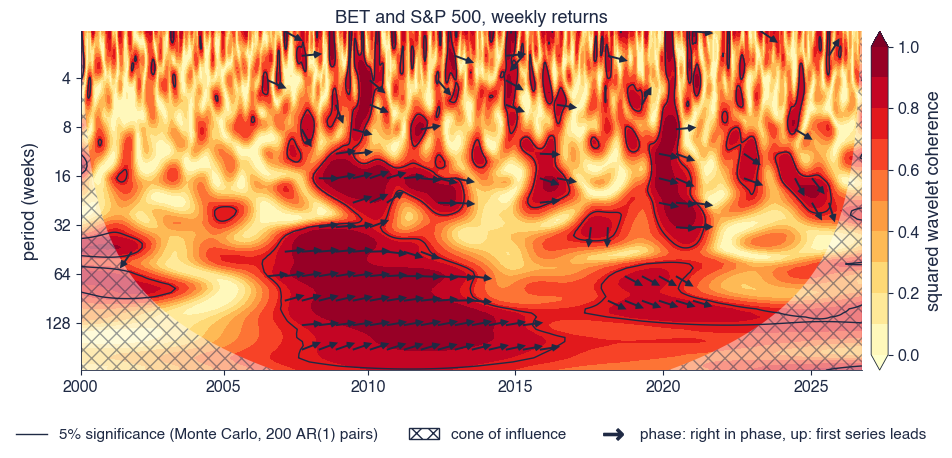

{'share_obs': 0.2593203022592336, 'null_mean': 0.04984082234559334, 'null_q95': 0.07412387231089516, 'null_max': 0.11807965147659805, 'ax': 0.03914343909539179, 'ay': -0.06747510440150585, 'n': 1379, 'reps': 200, 'null_any': 1.0, 'reps_check': 200, 'phase_sig': -0.08204387313799771, 'gfc': 0.7618246655218017, 'gfc_ph': 0.01734149522651922, 'calm': 0.4781949273765607, 'calm_ph': -0.5362314757074349, 'early': 0.3891383990782056, 'early_ph': -1.2413510494931932, 'covid': 0.688057150919973, 'covid_ph': -0.1673822150174427, 'short_all': 0.41857575711794215, 'short_all_ph': -0.2200279338826136}


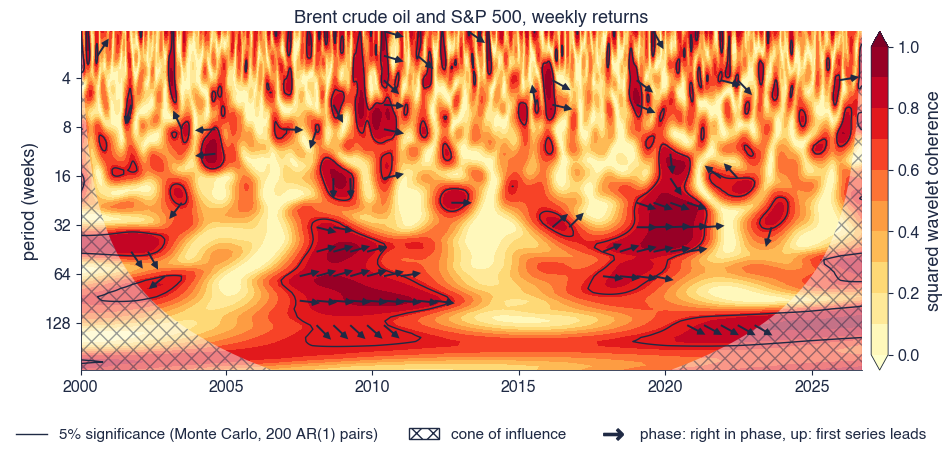

{'share_obs': 0.15583152111708826, 'null_mean': 0.052000877494181835, 'null_q95': 0.0790479188127122, 'null_max': 0.09627637251535615, 'ax': 0.08831674909876239, 'ay': -0.07293628080236506, 'n': 1392, 'reps': 200, 'null_any': 1.0, 'reps_check': 200, 'phase_sig': -0.3406406243770298, 'early': 0.4105487314873961, 'early_ph': -1.8640838200715677, 'gfc': 0.6984128768256128, 'gfc_ph': -0.09346008962715503, 'covid': 0.5803904460556597, 'covid_ph': -0.3660956018587026, 'war': 0.44139392398513966, 'war_ph': -2.312145957913727, 'calm': 0.4716425464721365, 'calm_ph': -0.017380566751811016, 'start': '2000-01-14', 'end': '2026-09-18'}


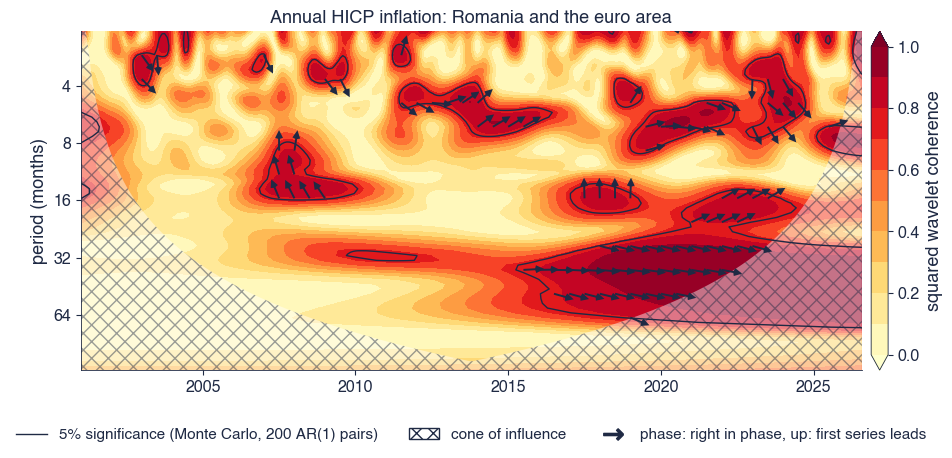

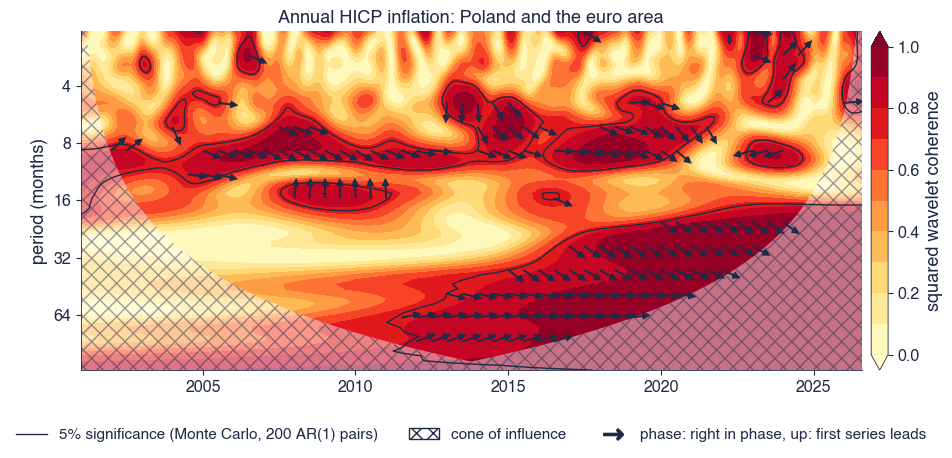

{'share_obs': 0.1740818338673897, 'null_mean': 0.05170446142469806, 'null_q95': 0.09605928025634702, 'null_max': 0.16200394380083805, 'ax': 0.9657858821863435, 'ay': 0.9815422524327189, 'n': 308, 'reps': 200, 'null_any': 1.0, 'reps_check': 200, 'phase_sig': 0.057183194864676816, 'post': 0.8467188394691157, 'post_ph': -0.19727554949412535, 'pre': 0.2280091948921254, 'pre_ph': -0.31657763684594126, 'surge': 0.7795593770303451, 'surge_ph': 0.14018302805133034, 'start': '2001-01-01', 'end': '2026-08-01', 'corr': 0.3414853983265526}


In [16]:
def fig_cwt_bet(save_it=True):
    """Morlet wavelet power of weekly BET returns (standardised), 2000-2026, with the 5% red-noise contour, the cone
    of influence, and the global wavelet spectrum."""
    y = weekly_returns('bet')
    c = cwt(y.values, dj=1 / 12, pmax=256)
    P = np.abs(c['W']) ** 2
    sig = red_noise_signif(y.values, c)
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw=dict(width_ratios=[4, 1]), sharey=True)
    cf = plot_tf(axs[0], np.log2(P), c, y.index, np.linspace(-4, 5, 19), sig=P / sig[:, None])
    axs[0].set_ylabel('period (weeks)')
    gws = P.mean(axis=1)
    a = ar1_coef(y.values)
    Pk = sig * 2 / stats.chi2.ppf(0.95, 2)                               # red-noise spectrum at each scale
    dof = 2 * np.sqrt(1 + (len(y) / (2.32 * c['scales'])) ** 2)          # Torrence-Compo eq. 23, Morlet gamma = 2.32
    lp = np.log2(c['period'])
    axs[1].plot(gws, lp, color=st.MainBlue, lw=1.8, label='global wavelet spectrum')
    axs[1].plot(Pk * stats.chi2.ppf(0.95, dof) / dof, lp, color=st.IDAred, ls='--', lw=1.2, label='5% red noise')
    axs[1].set_xlabel('power')
    cb = fig.colorbar(cf, ax=axs[0], pad=0.01)
    cb.set_label('$\\log_2$ power')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    save('ats_ch11_cwt_bet', save_it)
    mask = coi_mask(c)
    Pm = np.where(mask, P, -np.inf)
    i, j = np.unravel_index(np.argmax(Pm), P.shape)
    big = (P / sig[:, None] > 1) & mask
    return dict(ar1=float(a), max_date=str(y.index[j].date()), max_per=float(c['period'][i]), n=len(y),
                share_sig=float(big.mean() / mask.mean()), share_sig_short=float(big[c['period'] < 16].mean()),
                gws_peak=float(c['period'][np.argmax(gws)]))


def wtc_pair(x, y, idx, name, title, reps=500, pmax=256, dj=1 / 12, lab_unit='weeks', bands=None, save_it=True):
    r = wtc_montecarlo(x, y, dj=dj, pmax=pmax, reps=reps, seed=SEED)
    b = r['base']
    sig = b['R2'] / r['thr'][:, None]
    fig, ax = plt.subplots(figsize=(12, 4.4))
    cf = plot_tf(ax, b['R2'], b['cwt'], idx, np.linspace(0, 1, 11), cmap='YlOrRd', sig=sig, phase=b['phase'],
                 arrows_where=(sig > 1) & r['mask'])
    ax.set_ylabel(f'period ({lab_unit})')
    ax.set_title(title)
    cb = fig.colorbar(cf, ax=ax, pad=0.01)
    cb.set_label('squared wavelet coherence')
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    hd = [Line2D([], [], color=st.DarkText, lw=1), Patch(facecolor='white', hatch='xx', edgecolor=st.DarkText),
          Line2D([], [], color=st.DarkText, marker='$\\rightarrow$', ls='', ms=14)]
    ax.legend(hd, [f'5% significance (Monte Carlo, {reps} AR(1) pairs)', 'cone of influence',
                   'phase: right in phase, up: first series leads'], loc='upper center', bbox_to_anchor=(0.5, -0.13),
              ncol=3, frameon=False)
    save(name, save_it)
    per = b['period']
    out = dict(share_obs=r['share_obs'], null_mean=float(r['share_null'].mean()), null_q95=float(np.quantile(r['share_null'], 0.95)),
               null_max=float(r['share_null'].max()), ax=r['ax'], ay=r['ay'], n=len(x), reps=reps,
               null_any=float((r['share_null'] > 0).mean()), reps_check=r['reps_check'])
    sigm = (sig > 1) & r['mask']
    out['phase_sig'] = float(np.angle(np.mean(np.exp(1j * b['phase'][sigm])))) if sigm.any() else float('nan')
    for k, (p0, p1, d0, d1) in (bands or {}).items():
        rows = (per >= p0) & (per <= p1)
        cols = (idx >= pd.Timestamp(d0)) & (idx <= pd.Timestamp(d1))
        sub = b['R2'][np.ix_(rows, cols)]
        out[k] = float(sub.mean())
        out[k + '_ph'] = float(np.angle(np.mean(np.exp(1j * b['phase'][np.ix_(rows, cols)]))))
    return out, r


def fig_wtc_bet_dax(save_it=True, reps=500):
    d = pd.concat([weekly_returns('bet'), weekly_returns('dax')], axis=1, join='inner').dropna()
    out, r = wtc_pair(d['bet'].values, d['dax'].values, d.index, 'ats_ch11_wtc_bet_dax', 'BET and DAX, weekly returns',
                      reps=reps, bands={'gfc': (8, 64, '2008-01-01', '2009-12-31'), 'calm': (8, 64, '2014-01-01', '2019-12-31'),
                                        'early': (8, 64, '2000-01-01', '2006-12-31'), 'covid': (8, 64, '2020-01-01', '2021-06-30'),
                                        'short_all': (2, 8, '2000-01-01', '2026-12-31')}, save_it=save_it)
    _MEM['wtc_bet_dax'] = r
    out['start'] = str(d.index[0].date())
    out['end'] = str(d.index[-1].date())
    return out


def fig_wtc_bet_spx(save_it=True, reps=500):
    d = pd.concat([weekly_returns('bet'), weekly_returns('sp500')], axis=1, join='inner').dropna()
    out, _ = wtc_pair(d['bet'].values, d['sp500'].values, d.index, 'ats_ch11_wtc_bet_spx', 'BET and S&P 500, weekly returns',
                      reps=reps, bands={'gfc': (8, 64, '2008-01-01', '2009-12-31'), 'calm': (8, 64, '2014-01-01', '2019-12-31'),
                                        'early': (8, 64, '2000-01-01', '2006-12-31'), 'covid': (8, 64, '2020-01-01', '2021-06-30'),
                                        'short_all': (2, 8, '2000-01-01', '2026-12-31')}, save_it=save_it)
    return out


def fig_wtc_oil(save_it=True, reps=500):
    d = pd.concat([brent_weekly(), weekly_returns('sp500')], axis=1, join='inner').dropna()
    out, _ = wtc_pair(d['brent'].values, d['sp500'].values, d.index, 'ats_ch11_wtc_oil', 'Brent crude oil and S&P 500, weekly returns',
                      reps=reps, bands={'early': (16, 128, '2000-01-01', '2007-06-30'), 'gfc': (16, 128, '2008-06-01', '2010-12-31'),
                                        'covid': (8, 64, '2020-01-01', '2021-12-31'), 'war': (8, 64, '2022-01-01', '2023-12-31'),
                                        'calm': (16, 128, '2012-01-01', '2019-12-31')}, save_it=save_it)
    out['start'] = str(d.index[0].date())
    out['end'] = str(d.index[-1].date())
    return out


def fig_wtc_infl(save_it=True, reps=500):
    """Wavelet coherence of annual HICP inflation, Romania and Poland with the euro area, monthly 2001-2026."""
    out = {}
    ea = hicp('EA')
    for geo in ('RO', 'PL'):
        d = pd.concat([hicp(geo), ea], axis=1, join='inner').dropna()
        o, _ = wtc_pair(d[geo].values, d['EA'].values, d.index, f'ats_ch11_wtc_infl_{geo.lower()}',
                        f'Annual HICP inflation: {GEO_LAB[geo]} and the euro area', reps=reps, pmax=128, lab_unit='months',
                        bands={'post': (24, 64, '2015-01-01', '2026-12-31'), 'pre': (24, 64, '2002-01-01', '2012-12-31'),
                               'surge': (12, 48, '2021-01-01', '2024-12-31')}, save_it=save_it)
        o['start'] = str(d.index[0].date())
        o['end'] = str(d.index[-1].date())
        o['corr'] = float(d[geo].corr(d['EA']))
        out[geo] = o
    return out


print(fig_cwt_bet(save_it=False))
print(fig_wtc_bet_dax(save_it=False, reps=200))
print(fig_wtc_bet_spx(save_it=False, reps=200))
print(fig_wtc_oil(save_it=False, reps=200))
print(fig_wtc_infl(save_it=False, reps=200)['RO'])

## 11. AI mini-case: how many islands does chance produce?

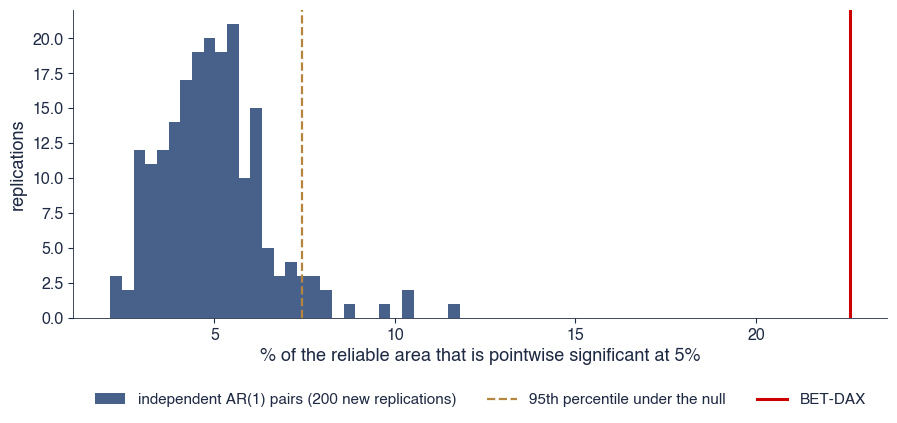

{'obs': 0.22608720795743698, 'mean': 0.04983735253296322, 'q95': 0.07425639987662885, 'max': 0.11805073637134705, 'any': 1.0, 'over10': 0.015, 'reps': 200}


In [17]:
def fig_ai_case(save_it=True):
    """Areawise check: the share of the reliable time-period area of the BET-DAX coherence that is pointwise
    significant at 5%, against its distribution over the Monte Carlo pairs of independent AR(1) series."""
    r = _MEM.get('wtc_bet_dax')
    if r is None:
        d = pd.concat([weekly_returns('bet'), weekly_returns('dax')], axis=1, join='inner').dropna()
        r = wtc_montecarlo(d['bet'].values, d['dax'].values, dj=1 / 12, pmax=256, reps=500, seed=SEED)
    sn = r['share_null']
    fig, ax = plt.subplots(figsize=(10.5, 4.0))
    ax.hist(100 * sn, bins=30, color=st.MainBlue, alpha=0.8, label=f'independent AR(1) pairs ({len(sn)} new replications)')
    ax.axvline(100 * np.quantile(sn, 0.95), color=st.Amber, ls='--', lw=1.6, label='95th percentile under the null')
    ax.axvline(100 * r['share_obs'], color=st.IDAred, lw=2.2, label='BET-DAX')
    ax.set_xlabel('% of the reliable area that is pointwise significant at 5%')
    ax.set_ylabel('replications')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    save('ats_ch11_ai_case', save_it)
    return dict(obs=float(r['share_obs']), mean=float(sn.mean()), q95=float(np.quantile(sn, 0.95)), max=float(sn.max()),
                any=float((sn > 0).mean()), over10=float((sn > 0.10).mean()), reps=int(len(sn)))


print(fig_ai_case(save_it=False))

## Exercises

1. Replace the HP filter by the boosted HP filter of Phillips and Shi (2021) and repeat the real-time comparison.
2. Compute the wavelet coherence of BET and DAX under a volatility-matched null: simulate from a DCC-GARCH with constant correlation (Chapter 8) instead of independent AR(1) pairs.
3. Apply singular spectrum analysis (`ssa`) to Romanian industrial production and compare its oscillatory pairs with the MODWT details.